# Directory for Figures tac

In [2]:
import os

# Définir le chemin de base et le répertoire à créer
base_dir = "G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2"
saving_dir = os.path.join(base_dir, "Plot_for_figure_tac2_svg")

# Vérifier si le répertoire existe, sinon le créer
if not os.path.exists(saving_dir):
    os.makedirs(saving_dir)
    print(f"Le répertoire '{saving_dir}' a été créé avec succès.")
else:
    print(f"Le répertoire '{saving_dir}' existe déjà.")

Le répertoire 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2\Plot_for_figure_tac2_svg' existe déjà.


## Modif des vectorisation du texte 

In [ ]:
# from matplotlib import rcParams

# # Forcer l'utilisation du texte en tant que texte dans SVG
# rcParams['svg.fonttype'] = 'none'
# rcParams['font.family'] = 'Myriad Pro'



# 1. Plot Thq rec exemple (2023.11.09 - T1)

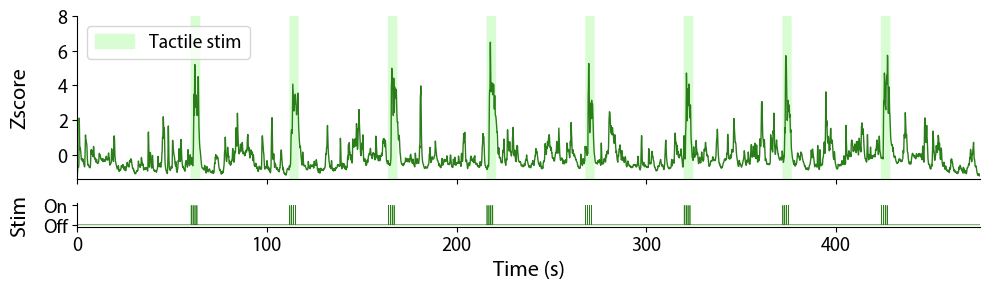

In [12]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 1. Chargement des données
final_df = pd.read_excel('G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2.xlsx', sheet_name='Master_sheet')

# 2. Définir l'animal et le rec souhaités
animal_tac = '2023.10.06'  # Remplacez par l'animal souhaité

# 3. Filtrage des données pour l'animal et le rec spécifiés
df_tac_filtered = final_df[(final_df['animal'] == animal_tac)].copy()

# 4. Conversion du temps en secondes pour les deux DataFrames
df_tac_filtered.loc[:, 'time_sec'] = df_tac_filtered['time'] / 1000

# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# 1er Subplot : Zscore rec raw
sns.lineplot(x='time_sec', y='Zscore', data=df_tac_filtered, ax=ax1, color='#2a7e19', linewidth=1, label=None)

# Ajuster les labels du premier subplot
ax1.set_ylabel('Zscore', labelpad=20)
ax1.set_ylim(-1.4, 8)
ax1.set_yticks([0, 2, 4, 6, 8])  # Définir les positions des graduations sur l'axe des ordonnées
ax1.set_yticklabels([0, 2, 4, 6, 8])  # Définir les étiquettes des graduations sur l'axe des ordonnées
ax1.set_xlim(0, 476)  # Définir les limites de l'axe des abscisses

# Définir les périodes "TS" pour les deux DataFrames avec des couleurs transparentes
thermic_color = '#d9fdd2'  #'#2fef10'  # Couleur pour la période thermic

# Périodes de stimulation thermiques
ts_periods_thermic = df_tac_filtered[df_tac_filtered['period'].str.startswith('TS_', na=False)].sort_values(by='time')
for i, row in ts_periods_thermic.iterrows():
    start_time_tac_raw = row['time'] / 1000
    end_time_tac_raw = (row['time'] + 2000) / 1000  # Conversion en secondes (3.9s)
    ax1.axvspan(start_time_tac_raw, end_time_tac_raw, color=thermic_color, zorder=0, label='Tactile stim')

# Suppression des duplicatas dans les légendes
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc='upper left')

# Définir les périodes de stimulation
stim_periods = {
    'TS_1': (60, 63),
    'TS_2': (112, 115),
    'TS_3': (164, 167),
    'TS_4': (216, 219),
    'TS_5': (268, 271),
    'TS_6': (320, 323),
    'TS_7': (372, 375),
    'TS_8': (424, 427)
}


# Générer une série temporelle pour tracer les pulses
time_series = np.linspace(0, df_tac_filtered['time_sec'].max(), int(df_tac_filtered['time_sec'].max() * 100))  # Temps échantillonné à 10 ms
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.05  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajout des pulses en fonction des périodes thermiques
for period, (start, end) in stim_periods.items():
    # Calculer les positions des 5 barres (espacées uniformément)
    pulse_times = np.linspace(start, end, num_pulses)

    # Placer les pulses dans la série temporelle
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Deuxième Subplot : Pulses carrés
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=0.5)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Stim', labelpad = 10)
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


plt.rcParams.update({
    'axes.labelsize': 16,   # Taille des labels des axes
    'xtick.labelsize': 14,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 14,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 14   # Taille de la police de la légende
})

plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Zscore_rec_Tac2.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Zscore_rec_Tac2.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()


# 2. Plot PSTC

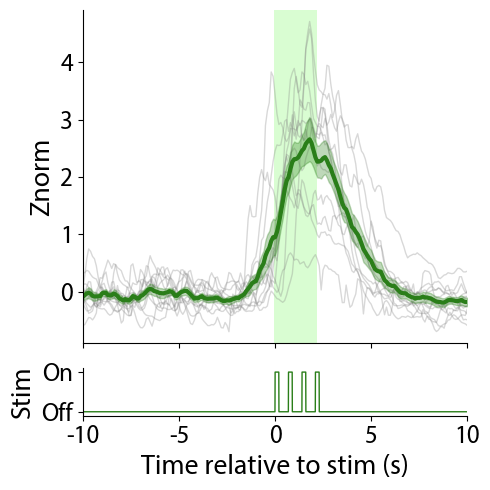

In [5]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np
from matplotlib import rcParams

# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Tac2_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_Zscore_classic_tactile2_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes

# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Création de la figure avec deux sous-graphes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax1, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax1.plot([], [], color=gray_color, linewidth=1, label='Animals trace')  # Légende unique

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax1.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#2a7e19', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax1.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#2a7e19', alpha=0.3, zorder=2, label=None
)

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Ajuster les limites de l'axe y
ax1.set_ylim(y_min - 0.1 * (y_max - y_min), y_max + 0.1 * (y_max - y_min))  # Ajouter une petite marge autour des données

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            df_combined['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax1.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)

# Ajouter la légende au premier subplot
ax1.set_ylabel('Znorm')

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax1.set_xlim(-10, 10)

# Ajuster les ticks de l'axe y 
time_range = (-10, 10)  # Définir la plage de temps sur laquelle calculer y_min et y_max
df_filtered_time = df_combined[(df_combined['time_sec'] >= time_range[0]) & (df_combined['time_sec'] <= time_range[1])]  # Filtrer les données
y_min_time_range = df_filtered_time['Mean_Znorm'].min()
y_max_time_range = df_filtered_time['Mean_Znorm'].max()
space = 0.2
ax1.set_ylim(y_min_time_range - space, y_max_time_range + space)

# Deuxième Subplot : Pulses carrés
# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

plt.tight_layout ()

# Sauvegarder les graphiques
plt.savefig(os.path.join(saving_dir, 'PSTC_tac2.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'PSTC_tac2.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()

# 3. Combo PSTC and Heatmap

La valeur maximale de Znorm est : 6.81740252782813


C:\Users\zayan\AppData\Local\Temp\ipykernel_21088\2978922332.py:76: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_heatmap_combined = df_tac.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
C:\Users\zayan\AppData\Local\Temp\ipykernel_21088\2978922332.py:285: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


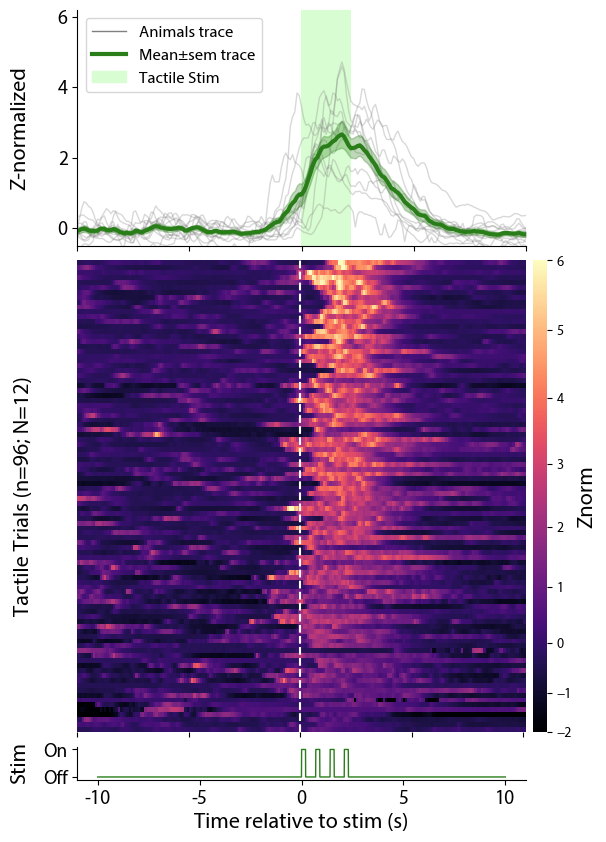

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import PowerNorm
from matplotlib.colors import Normalize
import os
import glob
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'


########################################################## PSTC #####################################################################


# Répertoire contenant les fichiers Excel
input_directory = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Tac2_Trial_Mean_SEM/'

# Trouver tous les fichiers correspondant au modèle
file_pattern = os.path.join(input_directory, 'Df_Zscore_classic_tactile2_*_trial_mean_SEM.xlsx')
files = glob.glob(file_pattern)

# Charger et combiner les données de tous les fichiers
dfs = []
for file_path in files:
    df = pd.read_excel(file_path)
    # Extraire la date et la partie du nom de fichier à partir du chemin du fichier Excel
    file_name = os.path.basename(file_path)
    save_file_name = file_name.split('_', 2)[2].replace('.xlsx', '')  # Garder la partie "2023.10.07_trial_mean"
    df['FileName'] = save_file_name
    dfs.append(df)
df_combined = pd.concat(dfs, ignore_index=True)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_combined['time_sec'] = df_combined['Stim_Time'] / 1000  # Conversion de Stim_Time en secondes


########################################################## HEATMAP #####################################################################

# Lire le fichier Excel
file_path_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2_stim.xlsx'
df_tac = pd.read_excel(file_path_tac)

# Trouver la valeur maximale de la colonne 'Znorm'
max_znorm_value = df_tac['Znorm'].max()
print("La valeur maximale de Znorm est :", max_znorm_value)

# Ajouter une colonne 'Stim' avec des identifiants uniques pour chaque trial
def add_stim_column(df, condition):
    trials_unique = df[['animal', 'trial']].drop_duplicates().reset_index(drop=True)
    trial_mapping = {idx: f'Stim_{idx+1}_{condition}' for idx in range(trials_unique.shape[0])}
    df['Stim'] = df.apply(lambda row: trial_mapping[trials_unique[(trials_unique['animal'] == row['animal']) & 
                                                                  (trials_unique['trial'] == row['trial'])].index[0]], axis=1)
    df['Condition'] = condition  # Ajouter une colonne Condition

add_stim_column(df_tac, 'Tactile')

# Convertir Stim_Time en secondes
df_tac['Stim_Time_sec'] = df_tac['Stim_Time'] / 1000

# Filtrer et calculer la somme de Znorm pour Stim_Time_sec entre 0 et 10 s, pour trier les trials
df_tac_filtered = df_tac[(df_tac['Stim_Time_sec'] >= 0) & (df_tac['Stim_Time_sec'] <= 10)]
trial_sums = df_tac_filtered.groupby('Stim')['Znorm'].max().sort_values(ascending=False)

# Réorganiser le DataFrame initial en fonction des trials triés par Znorm total
df_tac['Stim'] = pd.Categorical(df_tac['Stim'], categories=trial_sums.index, ordered=True)
df_tac = df_tac.sort_values('Stim')

# Créer la heatmap pour le DataFrame trié
df_heatmap_combined = df_tac.pivot_table(index='Stim', columns='Stim_Time_sec', values='Znorm', aggfunc='mean')
df_heatmap_combined = df_heatmap_combined.join(df_tac[['Stim', 'Condition']].drop_duplicates().set_index('Stim'))


########################################################## FIGURE #####################################################################


# Création de la figure avec GridSpec pour inclure le nouveau plot
fig = plt.figure(figsize=(7, 10))
gs = gridspec.GridSpec(nrows=3, ncols=2, width_ratios=[10, 1], height_ratios=[5, 10, 0.7], hspace=0.06)

######## PLOTING - PTSC ########

ax0 = plt.subplot(gs[0, 0])

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'  # light light blue

# Tracer les courbes pour chaque fichier en gris
unique_files = df_combined['FileName'].unique()
for file_name in unique_files:
    df_file = df_combined[df_combined['FileName'] == file_name]
    
    # Couleur gris pour toutes les courbes individuelles
    gray_color = 'gray'
    
    # Tracer la courbe du Mean Znorm
    sns.lineplot(
        data=df_file, x='time_sec', y='Mean_Znorm', 
        color=gray_color, linewidth=1, ax=ax0, alpha=0.3, label=None  # Pas de label pour chaque courbe
    )

# Suppression des duplicatas dans les légendes
ax0.plot([], [], color=gray_color, linewidth=1, label='Animals trace')  # Légende unique

# Calculer la courbe moyenne des animaux
mean_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].mean().reset_index()
ax0.plot(
    mean_zscore['time_sec'], mean_zscore['Mean_Znorm'], 
    color='#2a7e19', linewidth=3, linestyle='-', label='Mean±sem trace'
)

# Calculer la SEM de la courbe moyenne des animaux
SEM_zscore = df_combined.groupby('time_sec')['Mean_Znorm'].sem().reset_index()

# Tracer l'ombre correspondant à SEM autour de Mean_Znorm
ax0.fill_between(
    mean_zscore['time_sec'], 
    mean_zscore['Mean_Znorm'] - SEM_zscore['Mean_Znorm'], 
    mean_zscore['Mean_Znorm'] + SEM_zscore['Mean_Znorm'], 
    color='#2a7e19', alpha=0.3, zorder=2, label=None
)

# Calculer les limites réelles pour l'axe y
y_min = df_combined['Mean_Znorm'].min()
y_max = df_combined['Mean_Znorm'].max()

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax0.fill_between(
            df_combined['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 10 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    ax0.fill_between(
        df_combined['time_sec'], 
        y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
        y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
        where=(df_combined['time_sec'] >= start_time) & (df_combined['time_sec'] <= end_time),
        color=color_ts, alpha=0.3, zorder=1
    )

# Ajouter une seule entrée de légende pour "Thermic Stim"
ax0.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)

# Ajuster les ticks et les légendes
ax0.set_ylabel('Z-normalized', labelpad = 20)
ax0.legend(loc = 'upper left')
ax0.set_xlim(-10, 10)
ax0.set_ylim(-0.5, 6.2)
ax0.set_xticks(range(-10, 11, 5))
ax0.set_xticklabels("")

# Enlever les bordures du haut et de droite
ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)


######## PLOTING - Heatmap ########

ax1 = plt.subplot(gs[1, 0])
cbar_ax = plt.subplot(gs[1, 1])

# Créer un gradient personnalisé de couleurs avec une normalisation
norm = PowerNorm(gamma=1.2, vmin=-2, vmax=6)
base_palette = sns.color_palette("magma", as_cmap=True)
heatmap_combined = sns.heatmap(df_heatmap_combined.drop(columns=['Condition']),
                               cmap=base_palette, norm=norm, cbar_ax=cbar_ax, ax=ax1)

# Ligne verticale pour marquer 0
ax1.axvline(x=df_heatmap_combined.columns.get_loc(0), color='white', linestyle='--', linewidth=1.5)


# Ajuster la colorbar
cbar = heatmap_combined.collections[0].colorbar
cbar.set_label('Znorm')
cbar.ax.tick_params(labelsize=10)  # Ajuster la taille des labels si nécessaire

# Calculer la position et la hauteur de la heatmap pour ajuster la colorbar
pos = ax1.get_position()  # [x0, y0, width, height]
cbar_ax.set_position([pos.x1 + 0.01, pos.y0, 0.02, pos.y1 - pos.y0])


# Définir les étiquettes de l'axe x (de -10 à 10 avec un pas de 5)
ax1.set_xticks([df_heatmap_combined.columns.get_loc(x) for x in [-10, -5, 0, 5, 10]])

ax1.set_yticks([])  # Supprimer les étiquettes de l'axe y
ax1.set_ylabel('')  # Supprimer les étiquettes de l'axe y

# Marquer les trials Tactile
num_tac_trials = len(df_heatmap_combined[df_heatmap_combined['Condition'] == 'Tactile'])
ax1.text(-20, num_tac_trials / 2, f'Tactile Trials (n={num_tac_trials}; N=12)', fontsize=16, color='black', va='center', ha='right', rotation='vertical')


################# Tactile stim #################

ax2 = plt.subplot(gs[2, 0])

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(df_combined))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in df_combined.iterrows():
    if row['period'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False

# Si la période TS se termine à la dernière ligne
if in_ts_period:
    end_time = df_combined['time_sec'].iloc[-1]
    pulse_times = np.linspace(start_time, end_time, num_pulses)
    for pulse_time in pulse_times:
        pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
        pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse

# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim', labelpad = 10)
ax2.set_xticks(range(-10, 11, 5))
ax2.set_xticklabels([str(i) for i in range(-10, 11, 5)])
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# Ajuster les tailles de polices globales
plt.rcParams.update({
    'axes.labelsize': 16,   # Taille des labels des axes
    'xtick.labelsize': 14,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 14,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 12   # Taille de la police de la légende
})

# Ajuster les marges et sauvegarder
plt.tight_layout()

# Sauvegarder la figure en PNG
plt.savefig(os.path.join(saving_dir, 'PHTC_heatmap_tac2.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'PHTC_heatmap_tac2.svg'), format='svg', dpi=300)

plt.show()


# 4. Ploting AUC

### 4.1. N = animals


Test de Friedman pour AUC_Znorm_persec (Tactile):
Chi-square: 24.0, p-value: 6.144212353328207e-06
Comparaisons post-hoc (AUC_Znorm_persec, Tactile) :
          PTS            TB            TS
PTS  1.000000  1.678755e-02  2.827858e-02
TB   0.016788  1.000000e+00  2.404829e-07
TS   0.028279  2.404829e-07  1.000000e+00


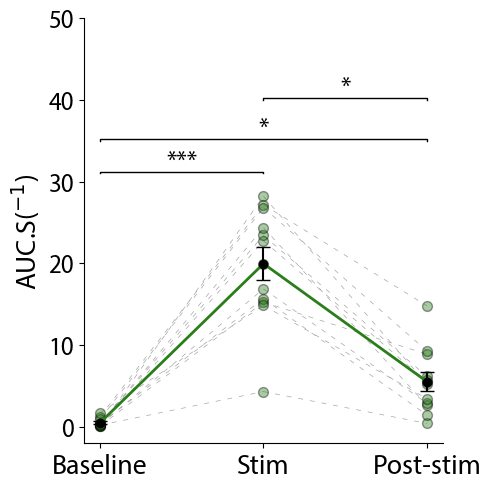

In [5]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import os
import matplotlib.lines as mlines

# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)

# Ajouter une colonne pour identifier la condition
df_auc_tac['Condition'] = 'Tactile'

# Définir les périodes
periods = ['TB', 'TS', 'PTS']

# Fonction pour effectuer le test de Friedman et les comparaisons post-hoc
def friedman_posthoc(df, variable_name, condition_name):
    friedman_test = friedmanchisquare(
        df[df['Period'] == 'PTS'][variable_name],
        df[df['Period'] == 'TB'][variable_name],
        df[df['Period'] == 'TS'][variable_name]
    )
    print(f"\nTest de Friedman pour {variable_name} ({condition_name}):")
    print(f"Chi-square: {friedman_test.statistic}, p-value: {friedman_test.pvalue}")

    posthoc_results = None
    if friedman_test.pvalue < 0.05:
        posthoc_results = posthoc_dunn(df, val_col=variable_name, group_col='Period', p_adjust='bonferroni')
        print(f"Comparaisons post-hoc ({variable_name}, {condition_name}) :")
        print(posthoc_results)
    return friedman_test, posthoc_results

# Appliquer le test de Friedman pour chaque variable
friedman_test_auc_tac, posthoc_results_auc_tac = friedman_posthoc(df_auc_tac, 'AUC_Znorm_persec', 'Tactile')

# Filtrer les données par période pour chaque variable
df_periods = {
    'Tactile': {period: df_auc_tac[(df_auc_tac['Period'] == period) & (df_auc_tac['Condition'] == 'Tactile')] for period in periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
colors = {'AUC_tac': '#2a7e19'
}
border_colors = {key: 'black' for key in colors}


# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_periods, condition_name, variable_name, color, border_color):
    means = {period: df_periods[condition_name][period][variable_name].mean() for period in periods}
    sems = {period: df_periods[condition_name][period][variable_name].sem() for period in periods}
    for period in periods:
        y_values = df_periods[condition_name][period][variable_name].values
        x_values = [positions[period]] * len(y_values)
        plt.scatter(x_values, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=50, zorder=1)
        mean_value = means[period]
        sem_value = sems[period]
        plt.errorbar(positions[period], mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems


# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))

means_tac, sems_tac = plot_variable(df_periods, 'Tactile', 'AUC_Znorm_persec', colors['AUC_tac'], border_colors['AUC_tac'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_tac'], label='Tactile')

# # Ajouter la légende avec les couleurs personnalisées
# plt.legend(handles=[legend_line_tactile], loc='upper left')


# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]], positions[periods[i + 1]]
        y1, y2 = means[periods[i]], means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_tac, 'AUC_tac', colors['AUC_tac'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_animal(df_auc_tac, condition_name, variable_name,color):
    # Filtrer par condition et par animal
    for animal in df_auc_tac[df_auc_tac['Condition'] == condition_name]['Animal'].unique():
        animal_data = df_auc_tac[(df_auc_tac['Condition'] == condition_name) & (df_auc_tac['Animal'] == animal)]
        
        # Relier les points pour chaque période pour cet animal
        for i, period in enumerate(periods[:-1]):
            x1 = positions[period] 
            x2 = positions[periods[i + 1]]
            y1 = animal_data[animal_data['Period'] == period][variable_name].values[0]
            y2 = animal_data[animal_data['Period'] == periods[i + 1]][variable_name].values[0]
            
            # Tracer une ligne entre les points
            plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10), linewidth=0.5, alpha=0.7, zorder=0)

plot_connections_per_animal(df_auc_tac, 'Tactile', 'AUC_Znorm_persec', colors['AUC_tac'])


def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.2, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Afficher les résultats du test de Dunn entre les périodes pour la condition tactile
y_offset = 27    # Initialisation du décalage vertical pour les barres de significativité
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc_results_auc_tac is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_auc_tac.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = positions[period_1]  # Position sur l'axe des x
                    x2 = positions[period_2]  # Position sur l'axe des x
                    significance_y_position = y_offset + idx + spacing_between_bars
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut




# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stim', 'Post-stim'])
plt.ylabel(r'AUC.S($^{-1}$)')
plt.ylim(-2, 50)
# plt.grid(axis='y')


plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

plt.tight_layout()


# Sauvegarder les graphiques
plt.savefig(os.path.join(saving_dir, 'AUC_tac_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_tac_animals.svg'), format='svg', dpi=300)

plt.show()


### 4.2. N = trials


Test de Friedman pour AUC_Znorm_persec (Tactile):
Chi-square: 152.77083333333326, p-value: 6.702472546636017e-34
Comparaisons post-hoc (AUC_Znorm_persec, Tactile) :
              PTS            TB            TS
PTS  1.000000e+00  7.190807e-08  8.758993e-15
TB   7.190807e-08  1.000000e+00  6.594358e-41
TS   8.758993e-15  6.594358e-41  1.000000e+00


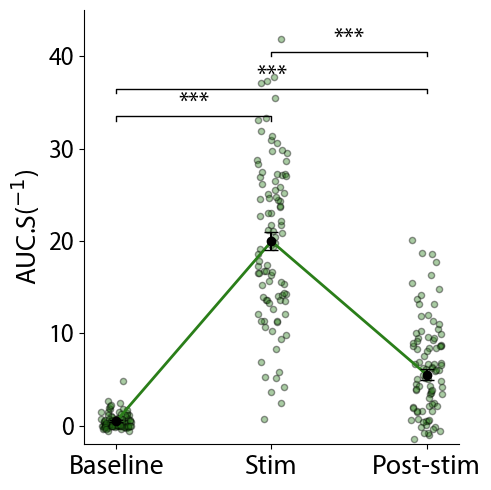

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from scikit_posthocs import posthoc_dunn
import matplotlib.lines as mlines
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemins vers les fichiers Excel pour chaque variable
file_path_auc_tac_trials = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'

# Charger les données
df_auc_tac_trial = pd.read_excel(file_path_auc_tac_trials)

# Ajouter une colonne pour identifier la condition
df_auc_tac_trial['Condition'] = 'Tactile'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac_trial['Period_type'] = df_auc_tac_trial['Period'].str.extract(r'([A-Za-z]+)')


# Définir les périodes
Periods = ['TB', 'TS', 'PTS']

# Fonction pour effectuer le test de Friedman et les comparaisons post-hoc
def friedman_posthoc(df, variable_name, condition_name):
    friedman_test = friedmanchisquare(
        df[df['Period_type'] == 'PTS'][variable_name],
        df[df['Period_type'] == 'TB'][variable_name],
        df[df['Period_type'] == 'TS'][variable_name]
    )
    print(f"\nTest de Friedman pour {variable_name} ({condition_name}):")
    print(f"Chi-square: {friedman_test.statistic}, p-value: {friedman_test.pvalue}")

    posthoc_results = None
    if friedman_test.pvalue < 0.05:
        posthoc_results = posthoc_dunn(df, val_col=variable_name, group_col='Period_type', p_adjust='bonferroni')
        print(f"Comparaisons post-hoc ({variable_name}, {condition_name}) :")
        print(posthoc_results)
    return friedman_test, posthoc_results

# Appliquer le test de Friedman pour chaque variable
friedman_test_auc_tac_trial, posthoc_results_auc_tac_trial = friedman_posthoc(df_auc_tac_trial, 'AUC_Znorm_persec', 'Tactile')

# Filtrer les données par période pour chaque variable
df_Periods = {
    'Tactile': {Period: df_auc_tac_trial[(df_auc_tac_trial['Period_type'] == Period) & (df_auc_tac_trial['Condition'] == 'Tactile')] for Period in Periods},
}

# Préparer les positions décalées et les couleurs
positions = {'TB': 1, 'TS': 2, 'PTS': 3}
colors = {
    'AUC_Znorm_persec_Tactile': '#2a7e19'
}
border_colors = {key: 'black' for key in colors}

# Fonction pour ajouter du jitter aux données
def add_jitter(x_values, jitter_strength=0.1):
    return x_values + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_values))

# Fonction pour tracer les points, les moyennes et les écarts-types pour chaque variable
def plot_variable(df_Periods, condition_name, variable_name, color, border_color):
    means = {Period: df_Periods[condition_name][Period][variable_name].mean() for Period in Periods}
    sems = {Period: df_Periods[condition_name][Period][variable_name].sem() for Period in Periods}
    for Period in Periods:
        y_values = df_Periods[condition_name][Period][variable_name].values
        x_values = [positions[Period]] * len(y_values)
        
        # Ajouter du jitter aux positions des points
        x_values_jittered = add_jitter(x_values)
        
        plt.scatter(x_values_jittered, y_values, color=color, edgecolor=border_color, linewidth=1, alpha=0.4, marker='o', s=20, zorder=1)
        mean_value = means[Period]
        sem_value = sems[Period]
        plt.errorbar(positions[Period], mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    return means, sems

# Tracer les données pour chaque variable
plt.figure(figsize=(5, 5))
means_tac, sems_tac = plot_variable(df_Periods, 'Tactile', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_Tactile'], border_colors['AUC_Znorm_persec_Tactile'])

# Créer des objets Line2D pour la légende avec les couleurs souhaitées
legend_line_tactile = mlines.Line2D([], [], color=colors['AUC_Znorm_persec_Tactile'], label='Tactile')

# # Ajouter la légende avec les couleurs personnalisées
# plt.legend(handles=[legend_line_tactile], loc='upper left')

# Ajouter des connexions entre les périodes
def plot_connections(means, variable_name, color):
    for i in range(len(Periods) - 1):
        x1, x2 = positions[Periods[i]], positions[Periods[i + 1]]
        y1, y2 = means[Periods[i]], means[Periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

plot_connections(means_tac, 'AUC_Znorm_persec_Tactile', colors['AUC_Znorm_persec_Tactile'])


# Ajouter des lignes reliant chaque point pour un même animal et condition
def plot_connections_per_trials_grouped(df_auc_tac_trial, condition_name, variable_name, color):
    # Filtrer par condition
    condition_data = df_auc_tac_trial[df_auc_tac_trial['Condition'] == condition_name]

    # Grouper les données par Animal, Rec et Trial
    grouped_data = condition_data.groupby(['Animal', 'Trial'])

    # Parcourir chaque groupe
    for (animal, trial), group in grouped_data:
        # Relier les points pour chaque période pour cet animal et cet enregistrement
        for i, Period in enumerate(Periods[:-1]):
            # Vérifier que les données des deux périodes existent
            if Period in group['Period'].values and Periods[i + 1] in group['Period'].values:
                x1 = positions[Period]
                x2 = positions[Periods[i + 1]]
                y1 = group[group['Period'] == Period][variable_name].values[0]
                y2 = group[group['Period'] == Periods[i + 1]][variable_name].values[0]

                # Tracer une ligne entre les points
                plt.plot([x1, x2], [y1, y2], color='grey', linestyle='--', dashes=(7, 10),
                         linewidth=0.5, alpha=0.7, zorder=0)

# Appeler la fonction pour tracer les connexions
plot_connections_per_trials_grouped(df_auc_tac_trial, 'Tactile', 'AUC_Znorm_persec', colors['AUC_Znorm_persec_Tactile'])


# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.35

def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# Afficher les résultats du test de Dunn entre les périodes pour la condition Tactile
y_offset = 30 # Initialisation du décalage vertical pour les barres de significativité
spacing_between_bars = 3  # Espacement entre chaque barre de significativité

if posthoc_results_auc_tac_trial is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_auc_tac_trial.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = positions[period_1]  # Position sur l'axe des x
                    x2 = positions[period_2]  # Position sur l'axe des x
                    significance_y_position = y_offset + idx + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


plt.xticks([positions[Period] for Period in Periods], ['Baseline', 'Stim', 'Post-stim'])
plt.ylabel(r'AUC.S($^{-1}$)')
plt.ylim(-2, 45)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})


plt.tight_layout()

# Sauvegarder les graphiques
plt.savefig(os.path.join(saving_dir, 'AUC_tac_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_tac_trials.svg'), format='svg', dpi=300)

plt.show()


# 5. Response rate by condition

### with N = animals

taux moyen de réponse tactile =89.58333333333333±6.122435558804777

Taille des échantillons : 12


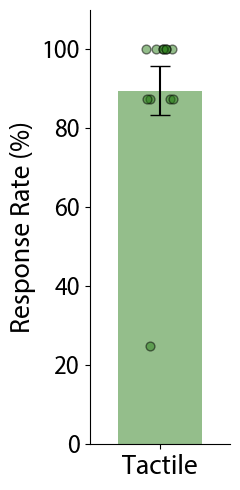

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin du fichier Excel
file_path_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Lecture du fichier Excel
df_tac_response = pd.read_excel(file_path_tac)

# Calcul du taux de réponse moyen par animal
response_data_tac = df_tac_response.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_tac['response_rate'] *= 100  # Conversion en pourcentage

# Calcul de la moyenne et de l'écart-type de réponse par animal
mean_response_per_animal = response_data_tac.groupby('animal')['response_rate'].mean()

# Calcul des statistiques globales
mean_response = mean_response_per_animal.mean()
sem_response = mean_response_per_animal.sem()
print (f"taux moyen de réponse tactile ={mean_response}±{sem_response}")
plt.figure(figsize=(2.5, 5))

# Tracé de la barre
plt.bar(
    [0.5],  # Position centrale pour la barre
    mean_response,
    width=0.6,  # Changez cette valeur pour ajuster la largeur
    yerr=sem_response,
    color='#2a7e19',
    alpha=0.5,
    capsize=7,
    label='tactile Stim'
)

# Ajout des points individuels avec jitter
np.random.seed(42)  # Assurer la reproductibilité
jitter = np.random.uniform(-0.1, 0.1, size=len(mean_response_per_animal))  # Générer un jitter aléatoire
x_positions = [0.5 + j for j in jitter]  # Ajouter le jitter autour de x=0.5

plt.scatter(
    x_positions,  # Utiliser les positions avec jitter
    mean_response_per_animal,
    color='#2a7e19',
    alpha=0.5,
    edgecolor='black',
    s=40
)


# Vérification des tailles d'échantillons
sample_size_tac = len(mean_response_per_animal)  # Taille de l'échantillon pour Tactile

print(f"\nTaille des échantillons : {sample_size_tac}")

# Mise en forme du graphique
plt.xticks([0.5], ['Tactile'])  # Placez l'étiquette au centre
plt.xlim(0, 1)  # Ajustez les limites pour encadrer la barre
plt.ylabel("Response Rate (%)")
plt.ylim(0, 110)


# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Response_rate_tac_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Response_rate_tac_animals.svg'), format='svg', dpi=300)

plt.show()


# 6. Above threshold rate

### 6.1. with n = animals


Test de normalité pour la période TB : n = 12
Statistique = 0.8622, p-value = 0.0521

Test de normalité pour la période TS : n = 12
Statistique = 0.9722, p-value = 0.9324

Test de normalité pour la période PTS : n = 12
Statistique = 0.9233, p-value = 0.3148

Résultats du Test de Friedman :
n (TB) = 12
n (TS) = 12
n (PTS) = 12
Statistique = 19.5000, p-value = 0.0001

Test de Dunn post-hoc pour comparer les périodes :
           TS        TB       PTS
TS   1.000000  0.000004  0.085657
TB   0.000004  1.000000  0.023816
PTS  0.085657  0.023816  1.000000


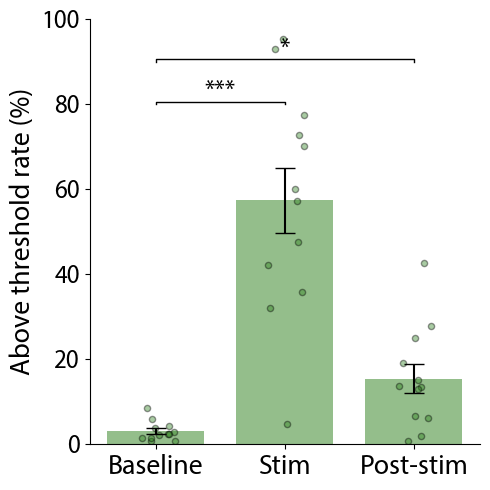

In [42]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for period in ['TB', 'TS', 'PTS']:
    period_data = df_tac[df_tac['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_tac_animal = df_tac.groupby(['animal', 'period_type'])['Norm_response_rate'].mean().reset_index()

# Moyenne des animaux pour chaque période (pour obtenir 1 valeur moyenne par période)
mean_tac = mean_tac_animal.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_tac = mean_tac_animal.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stim', 'Post-stim'],
    'mean_response_tac': mean_tac['Norm_response_rate'],
    'sem_response_tac': sem_tac['Norm_response_rate']
})

# Effectuer le test de normalité pour chaque période
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    period_data = mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')

# Effectuer le test de Friedman pour les périodes
print("\nRésultats du Test de Friedman :")
friedman_results = {}

# Organiser les données par période
period_data = [mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results['p_value'] = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")

# Initialiser posthoc_results
posthoc_results = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour comparer les périodes
    print("\nTest de Dunn post-hoc pour comparer les périodes :")
    
    # Test de Dunn post-hoc
    posthoc_results = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results)

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Tactile
plt.bar(mean_response_data['period'],
        height=mean_response_data['mean_response_tac'],
        width=bar_width, 
        yerr=mean_response_data['sem_response_tac'],
        label='Tactile', 
        color='#2a7e19', 
        alpha=0.5, 
        capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    tac_values = mean_tac_animal[mean_tac_animal['period_type'] == period]['Norm_response_rate']
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque période avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4)

# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 70  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
# y_offset = max(mean_response_data['mean_response_tac']) * 0.25  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 10  # Espacement entre chaque barre de significativité

if posthoc_results is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_data['period'])
# plt.legend(loc='upper left')
plt.ylim(0, 100)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Tac_Above_threshold_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Tac_Above_threshold_animals.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()


### 6.2. with n = Trials


Test de normalité pour la période TB : n = 96
Statistique = 0.7959, p-value = 0.0000

Test de normalité pour la période TS : n = 96
Statistique = 0.9109, p-value = 0.0000

Test de normalité pour la période PTS : n = 96
Statistique = 0.9038, p-value = 0.0000

Résultats du Test de Friedman :
n (TB) = 96
n (TS) = 96
n (PTS) = 96
Statistique = 120.8483, p-value = 0.0000

Test de Dunn post-hoc pour comparer les périodes :
               TS            TB           PTS
TS   1.000000e+00  1.415767e-30  1.497881e-06
TB   1.415767e-30  1.000000e+00  1.594804e-10
PTS  1.497881e-06  1.594804e-10  1.000000e+00


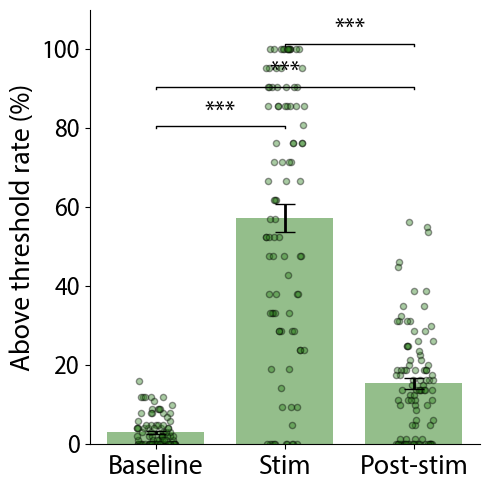

In [46]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, shapiro, friedmanchisquare
import numpy as np
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Spécifier le chemin des fichiers Excel
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Norm_response_rate.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_tac_trial = df_tac[df_tac['period_type'].isin(['TS', 'TB', 'PTS'])]

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = df_tac_trial.groupby('period_type')['Norm_response_rate'].mean().reset_index()
sem_tac = df_tac_trial.groupby('period_type')['Norm_response_rate'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_trial = pd.DataFrame({
    'period': ['Baseline', 'Stim', 'Post-stim'],
    'mean_response_tac': mean_tac['Norm_response_rate'],
    'sem_response_tac': sem_tac['Norm_response_rate']
})

# Effectuer le test de normalité pour chaque période
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}
    period_data = df_tac_trial[df_tac_trial['period_type'] == period]['Norm_response_rate']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour les périodes
print("\nRésultats du Test de Friedman :")
friedman_results = {}

# Organiser les données par période
period_data = [df_tac_trial[df_tac_trial['period_type'] == period]['Norm_response_rate'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results['p_value'] = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")

# Initialiser posthoc_results
posthoc_results = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour comparer les périodes
    print("\nTest de Dunn post-hoc pour comparer les périodes :")
    
    # Test de Dunn post-hoc
    posthoc_results = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results)

# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période
bar_width = 0.75
x = range(len(mean_response_trial['period']))

# Barres pour la condition tactile sans erreur (seulement les barres)
plt.bar(mean_response_trial['period'],
        height=mean_response_trial['mean_response_tac'],
        width=bar_width, 
        label='Tactile', 
        color='#2a7e19', 
        alpha=0.5, 
        zorder=0
        )

# Ajouter les barres d'erreur pour chaque période (en utilisant plt.errorbar)
plt.errorbar(mean_response_trial['period'],
             mean_response_trial['mean_response_tac'],
             yerr=mean_response_trial['sem_response_tac'],
             fmt='none',  # Pas de marqueur supplémentaire pour les erreurs
             ecolor='black',  # Couleur des erreurs
             capsize=7,       # Taille des caps pour les erreurs
             elinewidth=2,    # Épaisseur des lignes d'erreur
             zorder=3         # Les erreurs seront au-dessus des barres
             )

# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    tac_values = df_tac_trial[df_tac_trial['period_type'] == period]['Norm_response_rate']
    
    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque période avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in tac_values],
                tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4, zorder=0)


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.5, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 70  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 10  # Espacement entre chaque barre de significativité

if posthoc_results is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars


                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
plt.ylabel("Above threshold rate (%)")
plt.xticks(x, mean_response_trial['period'])
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})


# Affichage du graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Tac_Above_threshold_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Tac_Above_threshold_trials.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()


# 7. Magnitude of the response

### 7.1. N = animals 

mean_tac_anima
           animal period_type  response_magnitude
0      2023.10.06         PTS            0.936005
1      2023.10.06          TB            0.029742
2      2023.10.06          TS            1.642358
3      2023.10.07         PTS            0.457348
4      2023.10.07          TB            0.066496
5      2023.10.07          TS            2.237937
6   2023.10.09_M1         PTS            0.680023
7   2023.10.09_M1          TB            0.047551
8   2023.10.09_M1          TS            2.434670
9   2023.10.09_M2         PTS            0.462282
10  2023.10.09_M2          TB            0.050685
11  2023.10.09_M2          TS            2.885872
12     2023.10.10         PTS            0.451897
13     2023.10.10          TB            0.105398
14     2023.10.10          TS            2.454790
15     2023.10.11         PTS            0.017159
16     2023.10.11          TB            0.065637
17     2023.10.11          TS            0.149912
18     2023.10.17         PTS      

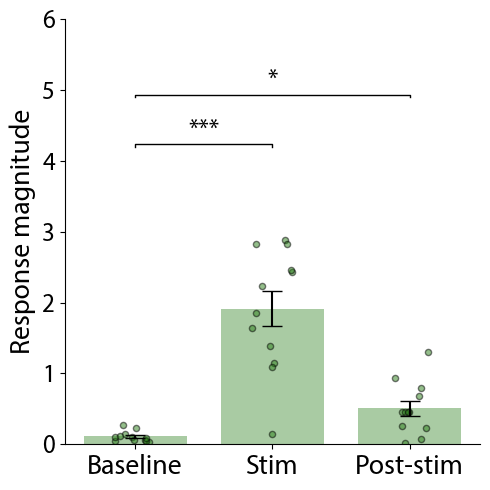

In [48]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, friedmanchisquare
import numpy as np
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Spécifier le chemin des fichiers Excel
# tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude.xlsx'
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude_norm.xlsx'

# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Vérification des tailles d'échantillons : s'assurer que chaque période a bien 24 observations par animal
for df, condition in zip([df_tac], ['Tactile']):

    # Compter le nombre d'observations par période et par animal
    sample_sizes = df.groupby(['animal', 'period_type']).size().reset_index(name='count')

    # Vérifier si toutes les périodes ont exactement 24 observations par animal
    for period in ['TB', 'TS', 'PTS']:
        period_data = sample_sizes[sample_sizes['period_type'] == period]

# Groupement des données par 'animal', 'period_type' et calcul de la moyenne pour chaque groupe
mean_tac_animal = df_tac.groupby(['animal', 'period_type'])['response_magnitude'].mean().reset_index()

print(f'mean_tac_anima')
print(mean_tac_animal)

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_tac = mean_tac_animal.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stim', 'Post-stim'],
    'mean_response_tac': mean_tac['response_magnitude'],
    'sem_response_tac': sem_tac['response_magnitude']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}

    data_subset = mean_tac_animal
    period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']

    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")

    stat, p_value = shapiro(period_data)
    normality_results[period] = {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour chaque condition (Cool et Hot)
print("\nRésultats du Test de Friedman :")
friedman_results = {}

data = mean_tac_animal

# Organiser les données par période
period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")


# Initialiser posthoc_results
posthoc_results_magnitude = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour chaque condition après le test de Friedman
    print("\nTest de Dunn pour comparer les périodes Thq :")

    data = mean_tac_animal

    # Organiser les données par période
    period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

    # Test de Dunn post-hoc
    posthoc_results_magnitude = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_results_magnitude.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_results_magnitude.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_results_magnitude)


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition tactile
plt.bar([p for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.4, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    Tac_values = mean_tac_animal[mean_tac_animal['period_type'] == period]['response_magnitude']

    # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in Tac_values],
                Tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.5)


# Ajouter les barres de significativité du test de Dunn
# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.03, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.03, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les périodes
y_offset = 3.5  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 0.7  # Espacement entre chaque barre de significativité

if posthoc_results_magnitude is not None:
    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_results_magnitude.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx 
                    x2 = jdx
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des périodes
                    # significance_y_position = max(mean_response_data['mean_response_tac'][idx], mean_response_data['mean_response_tac'][jdx]) + y_offset
                    significance_y_position = y_offset + idx + spacing_between_bars


                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Tac_response_magnitude_animal.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Tac_response_magnitude_animal.svg'), format='svg', dpi=300)

plt.show()


### 7.2. N = Trials

            animal    trial period age sexe  response_magnitude period_type
0    2023.10.09_M1  Trial_1   TB_1  P6    F            0.032440          TB
1    2023.10.09_M1  Trial_1   TS_1  P6    F            3.804984          TS
2    2023.10.09_M1  Trial_1  PTS_1  P6    F            0.742432         PTS
3    2023.10.09_M1  Trial_2   TB_2  P6    F            0.000000          TB
4    2023.10.09_M1  Trial_2   TS_2  P6    F            2.046010          TS
..             ...      ...    ...  ..  ...                 ...         ...
283     2023.10.07  Trial_7   TS_7  P8    F            2.778933          TS
284     2023.10.07  Trial_7  PTS_7  P8    F            0.867610         PTS
285     2023.10.07  Trial_8   TB_8  P8    F            0.041340          TB
286     2023.10.07  Trial_8   TS_8  P8    F            3.002691          TS
287     2023.10.07  Trial_8  PTS_8  P8    F            0.432372         PTS

[288 rows x 7 columns]

Test de normalité pour la période TB : n = 96
Statistique = 0.8

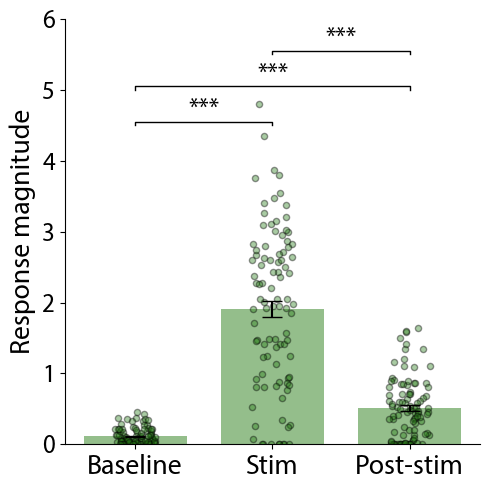

In [50]:
import os
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import shapiro, friedmanchisquare
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'


# Spécifier le chemin des fichiers Excel
# tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude.xlsx'
tac_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_Response_Magnitude_norm.xlsx'


# Lecture des fichiers Excel
df_tac = pd.read_excel(tac_file_path)

# Extraire uniquement le type de période (TS, TB, PTS) sans les indices
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Compter le nombre d'observations par période et par animal
sample_sizes = df_tac.groupby(['animal', 'period_type']).size().reset_index(name='count')

# Vérifier si toutes les périodes ont exactement 24 observations par animal
for period in ['TB', 'TS', 'PTS']:
    period_data = sample_sizes[sample_sizes['period_type'] == period]

# Extraire le type de période (TS, TB, PTS)
df_tac['period_type'] = df_tac['period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données par period_type
df_tac_filtered = df_tac[df_tac['period_type'].isin(['TS', 'TB', 'PTS'])]

print (df_tac_filtered)

# Moyenne des animaux pour chaque période et condition (pour obtenir 1 valeur moyenne par période)
mean_tac = df_tac_filtered.groupby('period_type')['response_magnitude'].mean().reset_index()
sem_tac = df_tac_filtered.groupby('period_type')['response_magnitude'].sem().reset_index()

# Réorganiser les données dans l'ordre TB, TS, PTS
period_order = ['TB', 'TS', 'PTS']

mean_tac = mean_tac.set_index('period_type').reindex(period_order).reset_index()
sem_tac = sem_tac.set_index('period_type').reindex(period_order).reset_index()

# Créer un DataFrame avec les moyennes et sem pour chaque période et chaque condition
mean_response_data = pd.DataFrame({
    'period': ['Baseline', 'Stim', 'Post-stim'],
    'mean_response_tac': mean_tac['response_magnitude'],
    'sem_response_tac': sem_tac['response_magnitude']
})

# Effectuer le test de normalité pour chaque période et condition
normality_results = {}
for period in ['TB', 'TS', 'PTS']:
    normality_results[period] = {}

    data_subset = df_tac_filtered
    period_data = data_subset[data_subset['period_type'] == period]['response_magnitude']
    
    # Affichage du nombre d'observations (n)
    n = len(period_data)
    print(f"\nTest de normalité pour la période {period} : n = {n}")
    
    stat, p_value = shapiro(period_data)
    normality_results[period]= {'statistic': stat, 'p_value': p_value}
    print(f'Statistique = {stat:.4f}, p-value = {p_value:.4f}')


# Effectuer le test de Friedman pour chaque condition
print("\nRésultats du Test de Friedman :")
friedman_results = {}

data = df_tac_filtered

# Organiser les données par période
period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

# Affichage du nombre d'observations (n) pour chaque période
for idx, period in enumerate(['TB', 'TS', 'PTS']):
    print(f"n ({period}) = {len(period_data[idx])}")

# Test de Friedman
stat_friedman, p_value_friedman = friedmanchisquare(*period_data)
friedman_results = p_value_friedman
print(f"Statistique = {stat_friedman:.4f}, p-value = {p_value_friedman:.4f}")


# Initialiser posthoc_results
posthoc_magnitude_trials = {}

# Si le test de Friedman est significatif, effectuer un test post-hoc de Dunn
if p_value_friedman < 0.05:
    # Test de Dunn post-hoc pour chaque condition après le test de Friedman
    print("\nTest de Dunn pour comparer les périodes Thq :")

    data = df_tac_filtered

    # Organiser les données par période
    period_data = [data[data['period_type'] == period]['response_magnitude'].values for period in ['TB', 'TS', 'PTS']]

    # Test de Dunn post-hoc
    posthoc_magnitude_trials = sp.posthoc_dunn(period_data, p_adjust='bonferroni')

    # Réorganisation de l'index et des colonnes avec des périodes
    posthoc_magnitude_trials.index = ['TS', 'TB', 'PTS']  # Définir les périodes comme index
    posthoc_magnitude_trials.columns = ['TS', 'TB', 'PTS']  # Définir les périodes comme colonnes

    # Sauvegarder les résultats de Dunn
    print(posthoc_magnitude_trials)


# Tracer les résultats
plt.figure(figsize=(5, 5))

# Barplot des taux de réponse moyens par période avec sem
bar_width = 0.75
x = range(len(mean_response_data['period']))

# Barres pour la condition Tactile
plt.bar([p for p in x], mean_response_data['mean_response_tac'],
        width=bar_width, yerr=mean_response_data['sem_response_tac'],
        label='Tactile', color='#2a7e19', alpha=0.5, capsize=7)


# Ajouter les points des trials
for period_idx, period in enumerate(['TB', 'TS', 'PTS']):
    # Extraire les valeurs de réponse par animal pour chaque période
    Tac_values = df_tac_filtered[df_tac_filtered['period_type'] == period]['response_magnitude']
     # Ajouter une légère variation aléatoire pour les positions en x afin de les distribuer autour des positions des barres
    jitter = 0.15  # ajuster cette valeur pour contrôler l'écart des points

    # Tracer les points pour chaque condition avec un écart autour de la position
    plt.scatter([period_idx + np.random.uniform(-jitter, jitter) for _ in Tac_values],
                Tac_values, color='#2a7e19', edgecolor='black', s=20, alpha=0.4)



# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.05, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Ajouter les barres de significativité
if isinstance(posthoc_magnitude_trials, pd.DataFrame):  # Vérifiez si c'est un DataFrame
    base_y_offset = 4  # Position de base pour les barres
    bar_spacing = 0.5  # Espacement fixe entre les barres

    for idx, period_1 in enumerate(['TB', 'TS', 'PTS']):
        for jdx, period_2 in enumerate(['TB', 'TS', 'PTS']):
            if idx < jdx:  # Comparer uniquement les paires distinctes
                p_val = posthoc_magnitude_trials.loc[period_1, period_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = idx
                    x2 = jdx
                    significance_y_position = base_y_offset + (idx + jdx) * bar_spacing
                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)
else:
    print("Les résultats du test de Dunn ne sont pas disponibles ou ne sont pas significatifs.")




# Titres et légendes
plt.xlabel('')
# plt.title("response_magnitude by conditions (N = trials)")
plt.ylabel("Response magnitude")
plt.xticks(x, mean_response_data['period'])
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim (0,6)

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

# Sauvegarder la figure
plt.savefig(os.path.join(saving_dir, 'Tac_response_magnitude_trial.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'Tac_response_magnitude_trial.svg'), format='svg', dpi=300)

plt.show()


# 9. Sex effect

## 9.1. PSTC

Nombre d'animaux mâles (M) : 5
Nombre d'animaux femelles (F) : 7


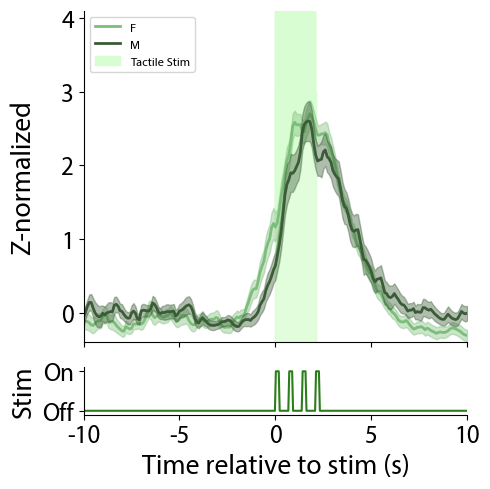

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2_stim.xlsx'

# Lire le fichier Excel
df_tactile = pd.read_excel(file_path)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_tactile['time_sec'] = df_tactile['Stim_Time'] / 1000

# Extraire le type de période (TB, TS, PTS)
df_tactile['Period_type'] = df_tactile['period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']

# Compter le nombre d'animaux par sexe
if 'animal' in df_tactile.columns:
    animal_count = df_tactile[['animal', 'sexe']].drop_duplicates().groupby('sexe').size()
    count_m = animal_count.get('M', 0)  # Nombre d'animaux mâles
    count_f = animal_count.get('F', 0)  # Nombre d'animaux femelles
    print(f"Nombre d'animaux mâles (M) : {count_m}")
    print(f"Nombre d'animaux femelles (F) : {count_f}")
else:
    print("La colonne 'animal' n'existe pas dans le fichier.")

# Grouper par 'sexe' et 'time_sec', puis calculer les moyennes et erreurs standards
grouped = df_tactile.groupby(['sexe', 'time_sec','Period_type']).agg(
    Mean_Zscore_norm=('Znorm', 'mean'),
    SEM_Zscore_norm=('Znorm', 'sem'),
).reset_index()

# Définir les couleurs pour chaque sexe
sex_colors = {
    'F': {'mean': '#7dbd7b', 'sem': '#7dbd7b'},  
    'M': {'mean': '#3a5c36', 'sem': '#3a5c36'}   
}

# Créer la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer les limites réelles pour l'axe y
y_min = grouped['Mean_Zscore_norm'].min()
y_max = grouped['Mean_Zscore_norm'].max()

# Tracer les courbes pour chaque sexe
for sexe, color in sex_colors.items():
    sexe_data = grouped[grouped['sexe'] == sexe]

    # Tracer la courbe moyenne pour le Z-score
    ax1.plot(
        sexe_data['time_sec'], sexe_data['Mean_Zscore_norm'],
        color=color['mean'], linewidth=2, label=f"{'F' if sexe == 'F' else 'M'}"
    )

    # Ajouter une zone ombrée pour le SEM
    ax1.fill_between(
        sexe_data['time_sec'],
        sexe_data['Mean_Zscore_norm'] - sexe_data['SEM_Zscore_norm'],
        sexe_data['Mean_Zscore_norm'] + sexe_data['SEM_Zscore_norm'],
        color=color['sem'], alpha=0.4, zorder=2
    )

# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            grouped['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False


# Ajouter une seule entrée de légende stim
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)


# Remplir la zone au-dessus de l'ombre de la SEM (jusqu'au haut du graphique)
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] + grouped['SEM_Zscore_norm'], 
    y_max +5,  # Limite supérieure réelle du graphique
    where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
    color=color_ts, zorder=0
)

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(grouped))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False


# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1.5)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized', labelpad=18)
ax1.legend(loc="upper left")

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.4, 4.1)
ax1.set_xlim(-10, 10)

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels("")
ax1.set_xlim(-10, 10)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax2.set_xlim(-10, 10)

# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)


#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})


# Affichage du graphique
plt.tight_layout()

# Sauvegarder les graphiques
plt.savefig(os.path.join(saving_dir, 'PSTC_tac_sexe.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'PSTC_tac_sexe.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()



## 9.2. AUC

##### 9.2.1.AUC (animals) --- ATTENTION STAT PAS FAITE

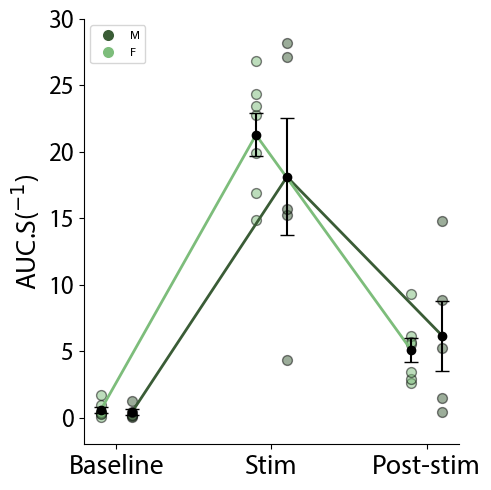

In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare
from scikit_posthocs import posthoc_dunn
import os
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'M' et 'F'
colors = {'M': '#3a5c36', 'F': '#7dbd7b'} #4a7c44
border_colors = {'M': 'black', 'F': 'black'}

# Fonction pour tracer les variables en fonction du sexe
def plot_variable_sex(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    
    # Calcul des moyennes et SEM par sexe
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        
        means[sex] = {period: sex_data[sex_data['Period'] == period][variable_name].mean() for period in periods}
        sems[sex] = {period: sex_data[sex_data['Period'] == period][variable_name].sem() for period in periods}

        # Tracer les données de chaque sexe avec décalage sur l'axe x
        for period in periods:
            x_offset = 0.1 if sex == 'M' else -0.1  # Décalage pour éviter le chevauchement
            x_values = [positions[period] + x_offset] * len(sex_data[sex_data['Period'] == period])
            y_values = sex_data[sex_data['Period'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(sex, 'gray'), edgecolor=border_colors.get(sex, 'black'),
                         linewidth=1, alpha=0.5, marker='o', s=50, zorder=1)
            
            mean_value = means[sex][period]
            sem_value = sems[sex][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    
    return means, sems

# Exemple d'appel pour afficher les graphiques pour la condition 'Tactile' et la variable 'AUC_Znorm_persec'
plt.figure(figsize=(5, 5))
means_sex, sems_sex = plot_variable_sex(df_auc_tac, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Fonction pour afficher les connexions entre les moyennes
def plot_connections(means, sex, variable_name, color):
    for i in range(len(periods) - 1):
        x1, x2 = positions[periods[i]] + (0.1 if sex == 'M' else -0.1), positions[periods[i + 1]] + (0.1 if sex == 'M' else -0.1)
        y1, y2 = means[sex][periods[i]], means[sex][periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Ensuite, appelez cette fonction pour chaque sexe
for sex in df_auc_tac['Sexe'].unique():
    plot_connections(means_sex, sex, 'AUC_Znorm_persec', colors[sex])

# Ajouter des résultats de tests statistiques, si nécessaires
y_offset = 4.5  # Décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre les barres de significativité

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stim', 'Post-stim'])
plt.ylabel(r'AUC.S($^{-1}$)')
plt.ylim (-2, 30)

# Ajouter la légende en haut à gauche avec les symboles des sexes
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['M'], markersize=9, label='M'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['F'], markersize=9, label='F')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)


plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})


plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_sexe_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_sexe_animals.svg'), format='svg', dpi=300)

plt.show()


##### 9.2.2. AUC of TS period (aniamls)

Statistique U : 16.0
p-value : 0.8762626262626263


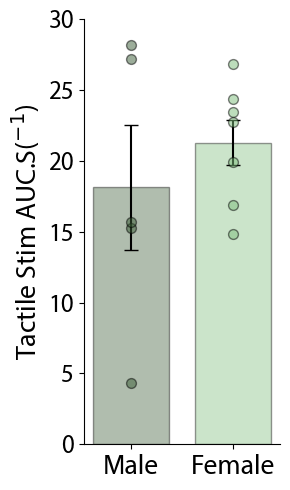

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import mannwhitneyu
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path_auc_tac = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac = pd.read_excel(file_path_auc_tac)

# Filtrer les données pour la période "TS" uniquement
df_ts = df_auc_tac[df_auc_tac['Period'] == 'TS']

# Définir les sexes uniques
sexes = df_ts['Sexe'].unique()

# Définir les couleurs pour chaque sexe
colors = {'M': '#3a5c36', 'F': '#7dbd7b'} #4a7c44
border_colors = {'M': 'black', 'F': 'black'}

# Extraire les données pour chaque sexe
male_data = df_ts[df_ts['Sexe'] == 'M']['AUC_Znorm_persec']
female_data = df_ts[df_ts['Sexe'] == 'F']['AUC_Znorm_persec']

# Test de Mann-Whitney U
stat, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

# Résultats
print(f"Statistique U : {stat}")
print(f"p-value : {p_value}")


# Initialiser le graphique
plt.figure(figsize=(3, 5))

# Tracer les barres pour chaque sexe
bar_width = 0.75
positions = range(len(sexes))
for i, sex in enumerate(sexes):
    sex_data = df_ts[df_ts['Sexe'] == sex]
    mean_auc = sex_data['AUC_Znorm_persec'].mean()
    sem_auc = sex_data['AUC_Znorm_persec'].sem()
    
    # Ajouter une barre
    plt.bar(
        positions[i],
        mean_auc,
        yerr=sem_auc,
        color=colors.get(sex, 'gray'),
        edgecolor=border_colors.get(sex, 'black'),
        width=bar_width,
        capsize=5,
        label='M' if sex == 'M' else 'F',
        alpha=0.4,
    )
    
    # Ajouter les points pour chaque animal
    x_values = [positions[i]] * len(sex_data)
    y_values = sex_data['AUC_Znorm_persec'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(sex, 'gray'),
        edgecolor=border_colors.get(sex, 'black'),
        alpha=0.5,
        marker='o',
        s=50,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, ['Male', 'Female'])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')
plt.ylim (0, 30)

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Appliquer les réglages de style
plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_sexe_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_sexe_animals.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()


#### 9.2.3. AUC (Trials) --- ATTENTION STAT PAS FAITE

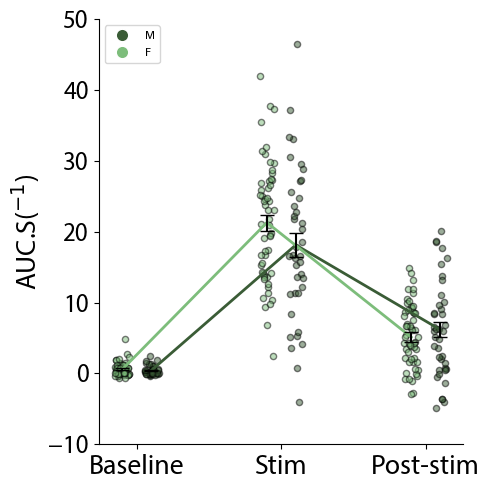

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare
from scikit_posthocs import posthoc_dunn
import os
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Ajouter une colonne 'Condition' si nécessaire
df_auc_tac2['Condition'] = 'Tactile'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'M' et 'F'
colors = {'M': '#3a5c36', 'F': '#7dbd7b'} #4a7c44
border_colors = {'M': 'black', 'F': 'black'}

# Fonction pour tracer les variables en fonction du sexe avec un "jitter"
def plot_variable_sex(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    
    # Calcul des moyennes et SEM par sexe
    for sex in df['Sexe'].unique():
        sex_data = df[df['Sexe'] == sex]
        
        means[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].mean() for period in periods}
        sems[sex] = {period: sex_data[sex_data['Period_type'] == period][variable_name].sem() for period in periods}

        # Tracer les données de chaque sexe avec un décalage sur l'axe x
        for period in periods:
            # Ajouter un jitter aléatoire pour éviter le chevauchement des points
            x_offset = 0.1 if sex == 'M' else -0.1  # Décalage pour éviter le chevauchement
            jitter = np.random.uniform(-0.05, 0.05, size=len(sex_data[sex_data['Period_type'] == period]))  # Jitter
            x_values = [positions[period] + x_offset + jitter[i] for i in range(len(sex_data[sex_data['Period_type'] == period]))]
            y_values = sex_data[sex_data['Period_type'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(sex, 'gray'), edgecolor=border_colors.get(sex, 'black'),
                         linewidth=1, alpha=0.5, marker='o', s=20, zorder=1)
            
            mean_value = means[sex][period]
            sem_value = sems[sex][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='-', color='black', capsize=5, zorder=2)
    
    return means, sems

# Appliquer la fonction pour chaque variable (ici, 'AUC_Znorm_persec')
plt.figure(figsize=(5, 5))

# Tracer les données pour la condition Tactile, dissociée par sexe
means_tac2, sems_tac2 = plot_variable_sex(df_auc_tac2, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Ajouter des connexions entre les périodes, avec un ajustement pour chaque sexe
def plot_connections(means, color, positions, periods, x_offsets):
    for i in range(len(periods) - 1):
        # Connexion entre les périodes, mais en fonction de la position réelle des moyennes
        x1 = positions[periods[i]] + x_offsets[periods[i]]
        x2 = positions[periods[i + 1]] + x_offsets[periods[i + 1]]
        y1 = means[periods[i]]
        y2 = means[periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Définir les décalages pour chaque sexe
x_offsets = {
    'M': {'TB': 0.1, 'TS': 0.1, 'PTS': 0.1},
    'F': {'TB': -0.1, 'TS': -0.1, 'PTS': -0.1}
}

# Ajouter des connexions pour chaque sexe avec les bons décalages
for sex in ['M', 'F']:
    plot_connections(means_tac2[sex], colors[sex], positions, periods, x_offsets[sex])


# Ajouter la légende en haut à gauche avec les symboles des sexes
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['M'], markersize=9, label='M'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['F'], markersize=9, label='F')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)


# Finaliser le graphique
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stim', 'Post-stim'])
plt.ylabel(r'AUC.S($^{-1}$)')
plt.ylim (-10, 50)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Appliquer les réglages de style
plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_sexe_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_sexe_trials.svg'), format='svg', dpi=300)

plt.tight_layout()
plt.show()


##### 9.2.4. AUC of TS period (trials)

Statistique U : 904.0
p-value : 0.10926534008217226
Mean (Male): 18.124110929668024
SEM (Male): 1.6825767548108377
Mean (Female): 21.281608014194934
SEM (Female): 1.1210832334752832


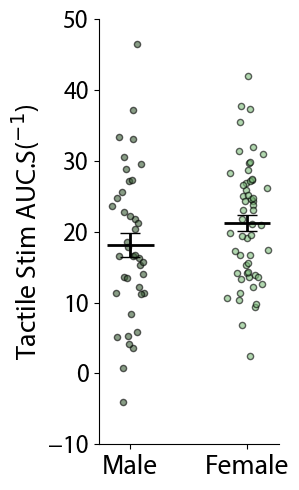

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Charger les données à partir du fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts = df_auc_tac2[df_auc_tac2['Period_type'] == 'TS']

# Définir les couleurs pour chaque sexe
colors = {'M': '#3a5c36', 'F': '#7dbd7b'} #4a7c44
border_colors = {'M': 'black', 'F': 'black'}

# Extraire les données pour chaque sexe
male_data = df_ts[df_ts['Sexe'] == 'M']['AUC_Znorm_persec']
female_data = df_ts[df_ts['Sexe'] == 'F']['AUC_Znorm_persec']

# Test de Mann-Whitney U
stat, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

# Afficher les résultats du test
print(f"Statistique U : {stat}")
print(f"p-value : {p_value}")

# Calcul de la moyenne et de l'erreur standard de la moyenne (SEM) pour chaque groupe
male_mean = male_data.mean()
female_mean = female_data.mean()
male_sem = male_data.sem()
female_sem = female_data.sem()

# Affichage des moyennes et des SEM
print(f"Mean (Male): {male_mean}")
print(f"SEM (Male): {male_sem}")
print(f"Mean (Female): {female_mean}")
print(f"SEM (Female): {female_sem}")

# Initialiser le graphique
plt.figure(figsize=(3, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points masculins
male_x = np.random.normal(0, jitter_strength, len(male_data))  # Jitter horizontal
plt.scatter(
    male_x, 
    male_data, 
    color=colors['M'], 
    edgecolor=border_colors['M'], 
    alpha=0.6, 
    marker='o', 
    s=20, 
    zorder=0
)

# Points féminins
female_x = np.random.normal(1, jitter_strength, len(female_data))  # Jitter horizontal
plt.scatter(
    female_x, 
    female_data, 
    color=colors['F'], 
    edgecolor=border_colors['F'], 
    alpha=0.6, 
    marker='o', 
    s=20, 
    zorder=0
)

# Tracer la ligne de la moyenne pour chaque sexe
plt.hlines(male_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(female_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  


# # Ajouter des barres d'erreur pour la SEM pour chaque sexe
plt.errorbar(0, male_mean, yerr=male_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, female_mean, yerr=female_sem, color='black', ecolor='black', elinewidth=2, capsize=7)

# Réglages des axes et de la légende
plt.xticks([0, 1], ['Male', 'Female'])  # Corriger l'ordre des labels
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')
plt.ylim(-10, 50)

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()


# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_sexe_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_sexe_trials.svg'), format='svg', dpi=300)

plt.show()


## 9.3. Response rate

##### 9.3.1 Response rate animals

Female condition: Mean = 94.64 ± SEM = 2.53
Male condition: Mean = 82.50 ± SEM = 14.58

Résultats des tests de normalité (Shapiro-Wilk) :
Male: Statistique = 0.6576, p-value = 0.0033
Female: Statistique = 0.6644, p-value = 0.0015
Test de Mann-Whitney : Statistique = 16.5000, p-value = 0.9262
Les taux de réponse des mâles et des femelles ne sont pas significativement différents.


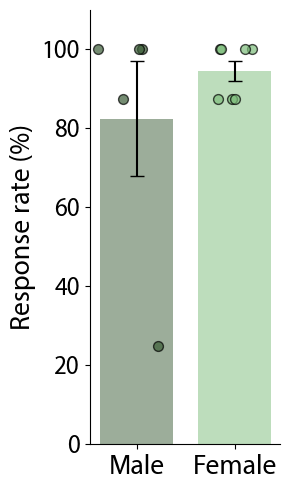

In [8]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np
from matplotlib import rcParams

# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin du fichier Excel
tac2_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Lecture du fichier Excel
df_tac2 = pd.read_excel(tac2_file_path)

# Séparer les données en fonction du sexe (M = Male, F = Female)
df_male = df_tac2[df_tac2['sexe'] == 'M']
df_female = df_tac2[df_tac2['sexe'] == 'F']

# Calcul du taux de réponse moyen par animal et par sexe
response_data_male = df_male.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_male['response_rate'] *= 100  # En pourcentage

response_data_female = df_female.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_female['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'sexe' pour différencier les groupes
response_data_male['sexe'] = 'Male'
response_data_female['sexe'] = 'Female'

# Combiner les données des deux sexes
combined_data = pd.concat([response_data_male, response_data_female])

# Calculer la moyenne du taux de réponse par animal pour chaque sexe
mean_response_per_animal = combined_data.groupby(['animal', 'sexe'])['response_rate'].mean().reset_index()

# Calcul des moyennes et SEM pour chaque sexe
mean_response_data = mean_response_per_animal.groupby('sexe').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Afficher la moyenne +/- SEM pour chaque sexe
for sexe in mean_response_data['sexe']:
    mean_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0]
    print(f"{sexe} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque sexe
mean_response_male = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Male']['response_rate']
mean_response_female = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Female']['response_rate']

normality_results = {
    "Male": stats.shapiro(mean_response_male),
    "Female": stats.shapiro(mean_response_female)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for sexe, result in normality_results.items():
    print(f"{sexe}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")

# Séparer les taux de réponse
response_male = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Male']['response_rate']
response_female = mean_response_per_animal[mean_response_per_animal['sexe'] == 'Female']['response_rate']

# Effectuer le test de Mann-Whitney
stat, p_value = mannwhitneyu(response_male, response_female)

print(f"Test de Mann-Whitney : Statistique = {stat:.4f}, p-value = {p_value:.4f}")

# Conclusion sur la comparaison statistique
if p_value < 0.05:
    print("Les taux de réponse des mâles et des femelles sont significativement différents.")
else:
    print("Les taux de réponse des mâles et des femelles ne sont pas significativement différents.")

# Tracer les résultats
plt.figure(figsize=(3, 5))

# Définir les couleurs et l'ordre
colors = ['#3a5c36', '#7dbd7b']  # Male: '#3a5c36', Female: '#7dbd7b'
sexe_order = ['Male', 'Female']

# Barplot des taux de réponse moyens par sexe avec SEM
bar_width = 0.75  # Réduire la largeur des barres
x = range(len(sexe_order))

for i, sexe in enumerate(sexe_order):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0],
        label=f'{sexe} Stim', color=colors[i], alpha=0.5, capsize=5
    )

# Ajouter des points individuels pour chaque sexe avec jitter
for i, (sexe, color) in enumerate(zip(sexe_order, colors)):
    individual_data = mean_response_per_animal[mean_response_per_animal['sexe'] == sexe]
    
    # Ajouter un jitter aléatoire pour décaler les points horizontalement
    jitter = 0.12 * np.random.randn(len(individual_data))
    x_offset = x[i]
    
    # Tracer les points avec jitter
    plt.scatter(
        [x_offset + j for j in jitter],
        individual_data['response_rate'],
        color=color,
        alpha=0.7,
        edgecolor='black',
        s=50
    )

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, sexe_order)
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Configuration des tailles de police
plt.rcParams.update({
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 18,
    'legend.fontsize': 10
})

# Affichage du graphique
plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'response_rate_sexe_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'response_rate_sexe_animals.svg'), format='svg', dpi=300)


plt.show()


##### 9.3.1 Response rate trials

Male condition: Mean = 82.50 ± SEM = 6.08
Female condition: Mean = 94.64 ± SEM = 3.04

Résultats des tests de normalité (Shapiro-Wilk) :
Male: Statistique = 0.4615, p-value = 0.0000
Female: Statistique = 0.2371, p-value = 0.0000
Test de Mann-Whitney : Statistique = 984.0000, p-value = 0.0570
Les taux de réponse des mâles et des femelles ne sont pas significativement différents.


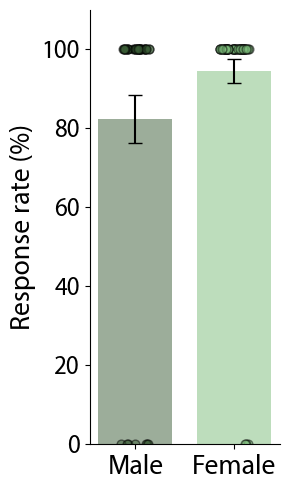

In [10]:
import os
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import numpy as np
from matplotlib import rcParams

# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin du fichier Excel
tac2_file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Lecture du fichier Excel
df = pd.read_excel(tac2_file_path)

# Séparer les données en fonction du sexe (M = Male, F = Female)
df_male = df[df['sexe'] == 'M']
df_female = df[df['sexe'] == 'F']

# Calcul du taux de réponse moyen par animal et par sexe
response_data_male = df_male.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_male['response_rate'] *= 100  # En pourcentage

response_data_female = df_female.groupby(['animal', 'trial'])['response_rate'].mean().reset_index()
response_data_female['response_rate'] *= 100  # En pourcentage

# Ajout de la colonne 'sexe' pour différencier les groupes
response_data_male['sexe'] = 'Male'
response_data_female['sexe'] = 'Female'

# Combiner les données des deux sexes
combined_data = pd.concat([response_data_male, response_data_female])

# Calcul des moyennes et SEM pour chaque sexe
mean_response_data = combined_data.groupby('sexe').agg(
    mean_response=('response_rate', 'mean'),
    sem_response=('response_rate', 'sem')
).reset_index()

# Réorganiser l'ordre des catégories : Male d'abord, puis Female
mean_response_data = mean_response_data.sort_values(by='sexe', key=lambda col: col.map({'Male': 0, 'Female': 1}))
mean_response_data = mean_response_data.reset_index(drop=True)

# Afficher la moyenne +/- SEM pour chaque sexe
for sexe in mean_response_data['sexe']:
    mean_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0]
    sem_value = mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0]
    print(f"{sexe} condition: Mean = {mean_value:.2f} ± SEM = {sem_value:.2f}")

# Vérifier la normalité (Shapiro-Wilk) pour chaque sexe
mean_response_male = combined_data[combined_data['sexe'] == 'Male']['response_rate']
mean_response_female = combined_data[combined_data['sexe'] == 'Female']['response_rate']

normality_results = {
    "Male": stats.shapiro(mean_response_male),
    "Female": stats.shapiro(mean_response_female)
}

print("\nRésultats des tests de normalité (Shapiro-Wilk) :")
for sexe, result in normality_results.items():
    print(f"{sexe}: Statistique = {result[0]:.4f}, p-value = {result[1]:.4f}")

# Effectuer le test de Mann-Whitney
response_male = combined_data[combined_data['sexe'] == 'Male']['response_rate']
response_female = combined_data[combined_data['sexe'] == 'Female']['response_rate']

stat, p_value = mannwhitneyu(response_male, response_female)

print(f"Test de Mann-Whitney : Statistique = {stat:.4f}, p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Les taux de réponse des mâles et des femelles sont significativement différents.")
else:
    print("Les taux de réponse des mâles et des femelles ne sont pas significativement différents.")

# Tracer les résultats
plt.figure(figsize=(3, 5))
bar_width = 0.75
x = range(len(mean_response_data['sexe']))

# Définir les couleurs pour chaque sexe dans le bon ordre
colors = ['#3a5c36', '#7dbd7b']  # Male = vert foncé, Female = vert clair

# Barres pour chaque sexe
for i, sexe in enumerate(mean_response_data['sexe']):
    plt.bar(
        x[i],
        mean_response_data.loc[mean_response_data['sexe'] == sexe, 'mean_response'].values[0],
        width=bar_width,
        yerr=mean_response_data.loc[mean_response_data['sexe'] == sexe, 'sem_response'].values[0],
        label=f'{sexe} Stim',
        color=colors[i],
        alpha=0.5,
        capsize=5
    )

# Ajouter des points individuels pour chaque sexe avec jitter
for sexe, color, x_position in zip(['Male', 'Female'], colors, x):
    individual_data = combined_data[combined_data['sexe'] == sexe]
    jitter = np.random.uniform(-0.15, 0.15, size=len(individual_data))
    x_values = x_position + jitter
    plt.scatter(
        x_values,
        individual_data['response_rate'],
        color=color,
        alpha=0.5,
        edgecolor='black',
        s=40
    )

# Mise en forme du graphique
plt.ylabel("Response rate (%)")
plt.xticks(x, mean_response_data['sexe'])
plt.ylim(0, 110)

# Enlever les bordures du haut et de droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mise à jour des paramètres de police
plt.rcParams.update({
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 18,
    'legend.fontsize': 10
})

# Sauvegarder les graphiques
plt.tight_layout()
plt.savefig(os.path.join(saving_dir, 'response_rate_sexe_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'response_rate_sexe_trials.svg'), format='svg', dpi=300)

# Affichage du graphique
plt.show()


#

#

# 10. Age effect

### 10.1. PSTC

Nombre de P6 : 3
Nombre de P7 : 4
Nombre de P8 : 5


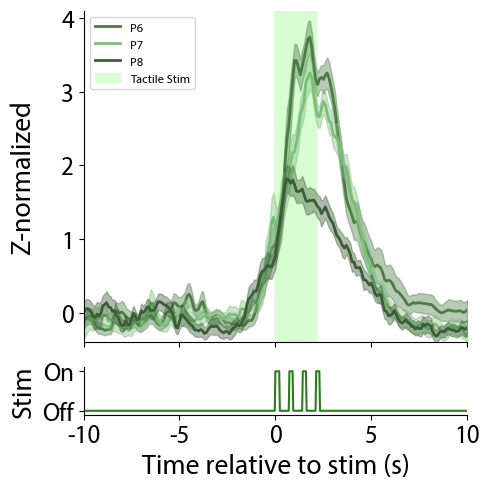

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Df_Zscore_classic_tactile2_stim.xlsx'

# Lire le fichier Excel
df_tac2 = pd.read_excel(file_path_tac2)

# Ajouter une colonne 'time_sec' en convertissant 'Stim_Time' en secondes
df_tac2['time_sec'] = df_tac2['Stim_Time'] / 1000

# Extraire le type de période (TB, TS, PTS)
df_tac2['Period_type'] = df_tac2['period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']

# Compter le nombre d'animaux par age
if 'animal' in df_tac2.columns:
    animal_count = df_tac2[['animal', 'age']].drop_duplicates().groupby('age').size()
    count_p6 = animal_count.get('P6', 0)  # Nombre d'animaux mâles
    count_p7 = animal_count.get('P7', 0)  # Nombre d'animaux femelles
    count_p8 = animal_count.get('P8', 0)  # Nombre d'animaux femelles
    print(f"Nombre de P6 : {count_p6}")
    print(f"Nombre de P7 : {count_p7}")
    print(f"Nombre de P8 : {count_p8}")
else:
    print("La colonne 'animal' n'existe pas dans le fichier.")

# Grouper par 'age' et 'time_sec', puis calculer les moyennes et erreurs standards
grouped = df_tac2.groupby(['age', 'time_sec','Period_type']).agg(
    Mean_Zscore_norm=('Znorm', 'mean'),
    SEM_Zscore_norm=('Znorm', 'sem'),
).reset_index()

age_colors = {
    'P6': {'mean': '#4a7c44', 'sem': '#4a7c44'},  # Bleu-vert clair
    'P7': {'mean': '#7dbd7b', 'sem': '#7dbd7b'},  # Vert plus sombre
    'P8': {'mean': '#3a5c36', 'sem': '#3a5c36'}   # Teinte plus sombre et intense
}

# Créer la figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), sharex=True, gridspec_kw={'height_ratios': [7, 1]})

# Calculer les limites réelles pour l'axe y
y_min = grouped['Mean_Zscore_norm'].min()
y_max = grouped['Mean_Zscore_norm'].max()


# Tracer les courbes pour chaque age
for age, color in age_colors.items():
    age_data = grouped[grouped['age'] == age]

    # Tracer la courbe moyenne pour le Z-score
    ax1.plot(
        age_data['time_sec'], age_data['Mean_Zscore_norm'],
        color=color['mean'], linewidth=2, label=f"{age}"
    )

    # Ajouter une zone ombrée pour le SEM
    ax1.fill_between(
        age_data['time_sec'],
        age_data['Mean_Zscore_norm'] - age_data['SEM_Zscore_norm'],
        age_data['Mean_Zscore_norm'] + age_data['SEM_Zscore_norm'],
        color=color['sem'], alpha=0.4, zorder=2
    )


# Définir les couleurs pour la période "TS"
color_ts = '#d9fdd2'

# Tracer la période TS en arrière-plan
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS
        ax1.fill_between(
            grouped['time_sec'], 
            y_min - 0.1 * (y_max - y_min),  # Limite inférieure réelle du graphique
            y_max + 0.1 * (y_max - y_min),  # Limite supérieure réelle du graphique
            where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
            color=color_ts, alpha=0.3, zorder=1
        )
        
        in_ts_period = False


# Ajouter une seule entrée de légende stim
ax1.fill_between(
    [], [], color=color_ts, alpha=1, label='Tactile Stim', zorder=1
)


# Remplir la zone au-dessus de l'ombre de la SEM (jusqu'au haut du graphique)
ax1.fill_between(
    grouped['time_sec'], 
    grouped['Mean_Zscore_norm'] + grouped['SEM_Zscore_norm'], 
    y_max +5,  # Limite supérieure réelle du graphique
    where=(grouped['time_sec'] >= start_time) & (grouped['time_sec'] <= end_time),
    color=color_ts, zorder=0
)

# Initialiser la série temporelle pour les pulses
time_series = np.linspace(-10, 10, len(grouped))  # Représentation de la série temporelle pour toute la période
pulse_series = np.zeros_like(time_series)

# Paramètres des pulses
pulse_width = 0.2  # Largeur d'un pulse (en secondes) réduite
num_pulses = 4  # Nombre de pulses par stimulation

# Ajouter les pulses dans la série temporelle, en prenant la période "TS" du premier subplot
in_ts_period = False
start_time = None
for i, row in grouped.iterrows():
    if row['Period_type'] == 'TS':
        if not in_ts_period:
            start_time = row['time_sec']
            in_ts_period = True
    elif in_ts_period:
        end_time = row['time_sec']
        
        # Remplir la zone pour la période TS dans le subplot 2 (ax2)
        pulse_times = np.linspace(start_time, end_time, num_pulses)
        for pulse_time in pulse_times:
            pulse_indices = np.where((time_series >= pulse_time) & (time_series < pulse_time + pulse_width))[0]
            pulse_series[pulse_indices] = 1  # Définir la hauteur du pulse
            
        in_ts_period = False


# Tracer les pulses sur le deuxième subplot
ax2.plot(time_series, pulse_series, color='#2a7e19', linewidth=1.5)

# Ajuster les ticks et les légendes
ax1.set_ylabel('Z-normalized', labelpad=18)
ax1.legend(loc="upper left")

# Limiter l'axe des X de -0.5 à 1
ax1.set_ylim(-0.4, 4.1)
ax1.set_xlim(-10, 10)

ax1.set_xticks([-10, -5, 0, 5, 10])
ax1.set_xticklabels("")
ax1.set_xlim(-10, 10)

# Ajuster les labels et l'échelle
ax2.set_xlabel('Time relative to stim (s)')
ax2.set_ylabel('Stim')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)  # Ajuster pour rendre les pulses visibles
ax2.set_yticklabels(['Off', 'On'])

ax2.set_xticks([-10, -5, 0, 5, 10])
ax2.set_xticklabels(['-10', '-5', '0', '5', '10'])
ax2.set_xlim(-10, 10)


# Ajuster l'espacement entre les sous-graphes
plt.subplots_adjust(hspace=0.06)

#Ajustement des bordures
# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Enlever les bordures du haut et de droite pour le deuxième subplot (ax2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 9   # Taille de la police de la légende
})

# Affichage du graphique
plt.tight_layout()

# Sauvegarder les graphiques
plt.savefig(os.path.join(saving_dir, 'PSTC_thq_age.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'PSTC_thq_age.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()


## 10.2. AUC age

#### 10.2.1. AUC (animals)

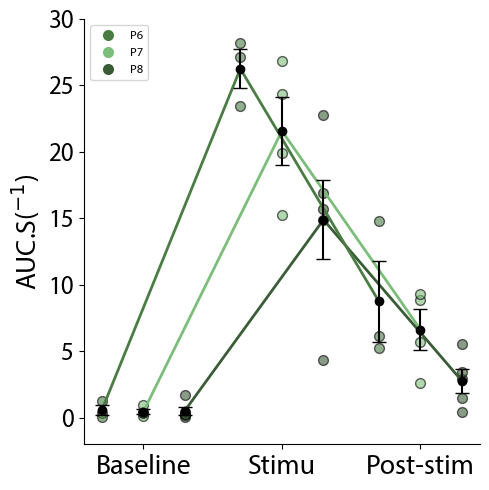

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare
from scikit_posthocs import posthoc_dunn
import os
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# Dictionnaire de couleurs mis à jour pour correspondre aux valeurs 'P6', 'P7' et 'P8'
# colors = {'P6': '#66d6c6', 'P7': '#0a9a7f', 'P8': '#075e4d'} #13bbaf
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Fonction pour tracer les variables en fonction de l'Age
def plot_variable_age(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    
    # Calcul des moyennes et SEM par Age
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        
        means[age] = {period: age_data[age_data['Period'] == period][variable_name].mean() for period in periods}
        sems[age] = {period: age_data[age_data['Period'] == period][variable_name].sem() for period in periods}

        # Tracer les données de chaque Age avec décalage sur l'axe x
        for period in periods:
            x_offset = 0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0)  # Décalage spécifique pour chaque âge
            x_values = [positions[period] + x_offset] * len(age_data[age_data['Period'] == period])
            y_values = age_data[age_data['Period'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(age, 'gray'), edgecolor=border_colors.get(age, 'black'),
                         linewidth=1, alpha=0.6, marker='o', s=50, zorder=1)
            
            mean_value = means[age][period]
            sem_value = sems[age][period]
            plt.errorbar(positions[period] + x_offset, mean_value, yerr=sem_value, fmt='o', color='black', capsize=5, zorder=2)
    
    return means, sems

# Exemple d'appel pour afficher les graphiques pour la condition 'Tactile' et la variable 'AUC_Znorm_persec'
plt.figure(figsize=(5, 5))
means_age, sems_age = plot_variable_age(df_auc_tac2, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Fonction pour afficher les connexions entre les moyennes
def plot_connections(means, age, variable_name, color):
    for i in range(len(periods) - 1):
        # Appliquer un décalage en fonction de l'âge pour chaque connexion
        x1 = positions[periods[i]] + (0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0))
        x2 = positions[periods[i + 1]] + (0.3 if age == 'P8' else (-0.3 if age == 'P6' else 0))
        y1, y2 = means[age][periods[i]], means[age][periods[i + 1]]
        plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Ensuite, appelez cette fonction pour chaque Age
for age in df_auc_tac2['Age'].unique():
    plot_connections(means_age, age, 'AUC_Znorm_persec', colors[age])

# Ajouter des résultats de tests statistiques, si nécessaires
y_offset = 4.5  # Décalage vertical pour les barres de significativité
spacing_between_bars = 2  # Espacement entre les barres de significativité

# Enlever les bordures du haut et de droite pour le premier subplot (ax1)
ax = plt.gca()  # Obtenir les axes actuels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Réglages finaux
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stim', 'Post-stim'])
plt.ylabel(r'AUC.S($^{-1}$)')
plt.ylim (-2,30)

# Ajouter la légende en haut à gauche avec les symboles des Ages
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P6'], markersize=9, label='P6'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P7'], markersize=9, label='P7'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P8'], markersize=9, label='P8')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})


plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_Age_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_Age_animals.svg'), format='svg', dpi=300)

plt.show()


#### 10.2.2. AUC TS (animals)

Statistique H : 6.271794871794874
p-value : 0.04346073310060689
          P6        P7        P8
P6  1.000000  0.678313  0.039281
P7  0.678313  1.000000  0.557469
P8  0.039281  0.557469  1.000000


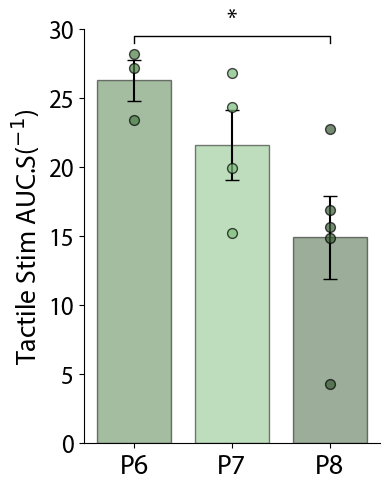

In [86]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'


# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_animal_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Filtrer les données pour la période "TS" uniquement
df_ts = df_auc_tac2[df_auc_tac2['Period'] == 'TS']

# Définir les âges uniques
ages = sorted(df_ts['Age'].unique())

# Définir les couleurs pour chaque âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [df_ts[df_ts['Age'] == age]['AUC_Znorm_persec'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(4, 5))

# Tracer les barres pour chaque âge
bar_width = 0.75
positions = range(len(ages))
for i, age in enumerate(ages):
    age_data = df_ts[df_ts['Age'] == age]
    mean_auc = age_data['AUC_Znorm_persec'].mean()
    sem_auc = age_data['AUC_Znorm_persec'].sem()
    
    # Ajouter une barre
    plt.bar(
        positions[i],
        mean_auc,
        yerr=sem_auc,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['AUC_Znorm_persec'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=50,
        zorder=2,
    )


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y + height_offset + 0.25, significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les âges
y_offset = 25  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc is not None:
    for i, age_1 in enumerate(ages):
        for j, age_2 in enumerate(ages):
            if i < j:  # Comparer uniquement les paires distinctes
                p_val = posthoc.loc[age_1, age_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = i 
                    x2 = j
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des âges
                    significance_y_position = y_offset + i + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')
plt.ylim (0, 30)

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Appliquer les réglages de style
plt.tight_layout()

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})


# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_age_animals.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_age_animals.svg'), format='svg', dpi=300)


# Afficher le graphique
plt.show()


#### 10.2.3. AUC (Trials) --- ATTENTION STAT PAS FAITE

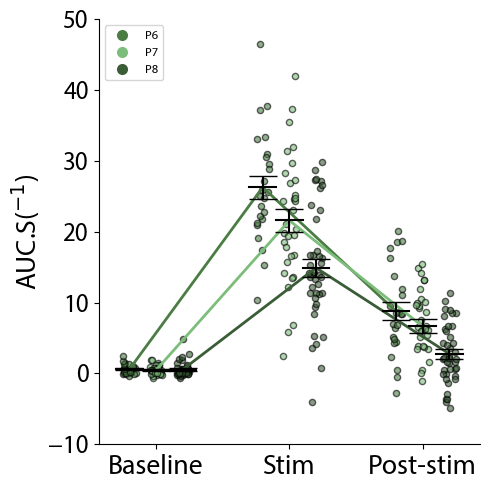

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare
from scikit_posthocs import posthoc_dunn
import os
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin vers le fichier Excel
file_path_auc_tac2 = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'

# Charger les données
df_auc_tac2 = pd.read_excel(file_path_auc_tac2)

# Ajouter une colonne 'Condition' si nécessaire
df_auc_tac2['Condition'] = 'Tactile'

# Extraire le type de période (TB, TS, PTS)
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Définir les périodes et positions associées
periods = ['TB', 'TS', 'PTS']
positions = {'TB': 0, 'TS': 1, 'PTS': 2}  # Positions des périodes sur l'axe des x

# # Définir les âges uniques
# ages = sorted(df_ts['Age'].unique())

# Définir les couleurs pour chaque âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Fonction pour tracer les variables avec un décalage et jitter améliorés
def plot_variable_age(df, variable_name, condition_name, colors, border_colors):
    means = {}
    sems = {}
    
    # Calcul des moyennes et SEM par Age
    for age in df['Age'].unique():
        age_data = df[df['Age'] == age]
        
        means[age] = {period: age_data[age_data['Period_type'] == period][variable_name].mean() for period in periods}
        sems[age] = {period: age_data[age_data['Period_type'] == period][variable_name].sem() for period in periods}

        # Définir un décalage fixe pour chaque âge
        age_offsets = {'P6': -0.2, 'P7': 0.0, 'P8': 0.2}
        x_offset = age_offsets.get(age, 0)

        # Tracer les données de chaque Age avec un décalage sur l'axe x
        for period in periods:
            # Ajouter un jitter limité pour éviter le chevauchement
            jitter = np.random.uniform(-0.05, 0.05, size=len(age_data[age_data['Period_type'] == period]))
            x_values = [positions[period] + x_offset + jitter[i] for i in range(len(age_data[age_data['Period_type'] == period]))]
            y_values = age_data[age_data['Period_type'] == period][variable_name].values
            
            # Tracer les points
            plt.scatter(x_values, y_values, color=colors.get(age, 'gray'), edgecolor=border_colors.get(age, 'black'),
                         linewidth=1, alpha=0.6, marker='o', s=20, zorder=1)

            # Tracer la moyenne et SEM pour chaque âge et période
            mean_value = means[age][period]
            sem_value = sems[age][period]

            # Tracer la moyenne avec une barre horizontale (petite ligne centrale)
            plt.plot(
                [positions[period] + x_offset - 0.1, positions[period] + x_offset + 0.1],
                [mean_value, mean_value],
                color='black', linewidth=1.5, zorder=3
            )

            # Tracer les barres d'erreur verticales (SEM)
            plt.errorbar(
                positions[period] + x_offset, mean_value,
                yerr=sem_value, color='black', capsize=10, linewidth=1.5, zorder=3
            )

    return means, sems

# Appliquer la fonction pour tracer
plt.figure(figsize=(5, 5))
means_tac2, sems_tac2 = plot_variable_age(df_auc_tac2, 'AUC_Znorm_persec', 'Tactile', colors, border_colors)

# Fonction pour tracer les connexions entre les moyennes
def plot_connections(means, color, positions, periods, x_offsets, zorder):
    """
    Trace des connexions entre les moyennes des périodes pour un âge donné.
    """
    for i in range(len(periods) - 1):
        # Obtenir les périodes actuelles
        period1 = periods[i]
        period2 = periods[i + 1]

        # Calcul des positions x et y pour les connexions
        x1 = positions[period1] + x_offsets.get(period1, 0)
        x2 = positions[period2] + x_offsets.get(period2, 0)
        y1 = means.get(period1, np.nan)
        y2 = means.get(period2, np.nan)

        # Vérifier que les moyennes ne sont pas manquantes
        if not np.isnan(y1) and not np.isnan(y2):
            plt.plot([x1, x2], [y1, y2], color=color, linestyle='-', linewidth=2, zorder=1)

# Définir les décalages pour chaque âge et chaque période
x_offsets = {
    'P6': {'TB': -0.2, 'TS': -0.2, 'PTS': -0.2},
    'P7': {'TB': 0.0, 'TS': 0.0, 'PTS': 0.0},
    'P8': {'TB': 0.2, 'TS': 0.2, 'PTS': 0.2}
}

# Ajouter des connexions pour chaque âge
for age in ['P6', 'P7', 'P8']:
    age_offsets = x_offsets[age]
    plot_connections(means_tac2[age], colors[age], positions, periods, age_offsets, zorder=2)



# Finaliser le graphique
plt.xticks([positions[period] for period in periods], ['Baseline', 'Stim', 'Post-stim'])
plt.ylabel(r'AUC.S($^{-1}$)')
plt.ylim (-10,50)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajouter une légende
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P6'], markersize=9, label='P6'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P7'], markersize=9, label='P7'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['P8'], markersize=9, label='P8')
]
plt.legend(handles=handles, loc='upper left', fontsize=9)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_age_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_age_trials.svg'), format='svg', dpi=300)

plt.show()


##### 10.2.4. AUC of TS period (trials)

kruskal Stat H : 23.299860395189
p-value : 8.719660994344179e-06
          P6        P7        P8
P6  1.000000  0.227544  0.000009
P7  0.227544  1.000000  0.006825
P8  0.000009  0.006825  1.000000
Mean P6: 26.260819460006644 ± 1.6121380468030875
Mean P7: 21.580431545935454 ± 1.5877734558907384
Mean P8: 14.897525236788585 ± 1.2716443605657664


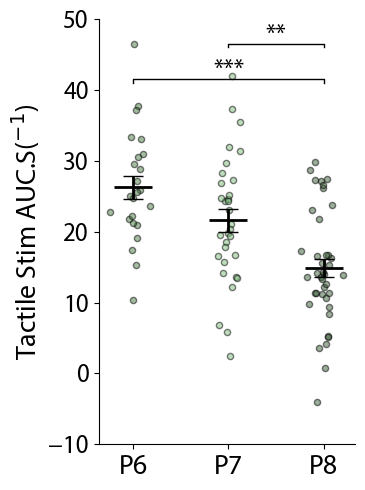

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'


# Charger les données à partir du fichier Excel
file_path_auc_tactile = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Quantif_by_Periods/AUC_persec_Znorm_by_Period_tac2.xlsx'
df_auc_tac2 = pd.read_excel(file_path_auc_tactile)

# Ajouter une colonne 'Period_type' à partir de la colonne 'Period'
df_auc_tac2['Period_type'] = df_auc_tac2['Period'].str.extract(r'([A-Za-z]+)')

# Filtrer les données pour la période 'TS'
df_ts_trials = df_auc_tac2[df_auc_tac2['Period_type'] == 'TS']

# Définir les couleurs pour chaque âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}
border_colors = {'P6': 'black', 'P7': 'black', 'P8': 'black'}

# Extraire les données pour chaque sexe
P6_data = df_ts_trials[df_ts_trials['Age'] == 'P6']['AUC_Znorm_persec']
P7_data = df_ts_trials[df_ts_trials['Age'] == 'P7']['AUC_Znorm_persec']
P8_data = df_ts_trials[df_ts_trials['Age'] == 'P8']['AUC_Znorm_persec']


# Définir les âges uniques
ages = sorted(df_ts_trials['Age'].unique())

# Extraire les données pour chaque groupe d'âge
data_by_age = [df_ts_trials[df_ts_trials['Age'] == age]['AUC_Znorm_persec'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"kruskal Stat H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df_ts_trials, val_col='AUC_Znorm_persec', group_col='Age', p_adjust='bonferroni')

# Résultats
print(posthoc)


# Calcul de la moyenne et de l'erreur standard de la moyenne (SEM) pour chaque groupe
P6_mean = P6_data.mean()
P7_mean = P7_data.mean()
P8_mean = P8_data.mean()

P6_sem = P6_data.sem()
P7_sem = P7_data.sem()
P8_sem = P8_data.sem()

# Affichage des moyennes et des SEM
print(f"Mean P6: {P6_mean} ± {P6_sem}")
print(f"Mean P7: {P7_mean} ± {P7_sem}")
print(f"Mean P8: {P8_mean} ± {P8_sem}")


# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Ajouter des points avec jitter
jitter_strength = 0.075  # Contrôler l'intensité du jitter

# Points masculins
p6_x = np.random.normal(0, jitter_strength, len(P6_data))  # Jitter horizontal
plt.scatter(
    p6_x, 
    P6_data, 
    color=colors['P6'], 
    edgecolor=border_colors['P6'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p7_x = np.random.normal(1, jitter_strength, len(P7_data))  # Jitter horizontal
plt.scatter(
    p7_x, 
    P7_data, 
    color=colors['P7'], 
    edgecolor=border_colors['P7'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)

p8_x = np.random.normal(2, jitter_strength, len(P8_data))  # Jitter horizontal
plt.scatter(
    p8_x, 
    P8_data, 
    color=colors['P8'], 
    edgecolor=border_colors['P8'], 
    alpha=0.5, 
    marker='o', 
    s=20, 
    zorder=0
)


# Tracer la ligne de la moyenne pour chaque sexe
plt.hlines(P6_mean, -0.2, 0.2, colors='black', linestyles='solid', linewidth=2)
plt.hlines(P7_mean, 0.8, 1.2, colors='black', linestyles='solid', linewidth=2)  
plt.hlines(P8_mean, 1.8, 2.2, colors='black', linestyles='solid', linewidth=2)  


# # Ajouter des barres d'erreur pour la SEM pour chaque sexe
plt.errorbar(0, P6_mean, yerr=P6_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(1, P7_mean, yerr=P7_sem, color='black', ecolor='black', elinewidth=2, capsize=7)
plt.errorbar(2, P8_mean, yerr=P8_sem, color='black', ecolor='black', elinewidth=2, capsize=7)


# Ajouter les barres de significativité du test de Dunn
def add_dunn_sig_bar(x1, x2, y, p_val, height_offset=0.5, fontsize=18):
    significance = ""
    if p_val < 0.001:
        significance = "***"
    elif p_val < 0.01:
        significance = "**"
    elif p_val < 0.05:
        significance = "*"

    if significance:
        plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
        plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)


# Afficher les résultats du test de Dunn entre les âges
y_offset = 37  # Initialiser le décalage vertical basé sur la valeur maximale des moyennes
spacing_between_bars = 4  # Espacement entre chaque barre de significativité

if posthoc is not None:
    for i, age_1 in enumerate(ages):
        for j, age_2 in enumerate(ages):
            if i < j:  # Comparer uniquement les paires distinctes
                p_val = posthoc.loc[age_1, age_2]
                if p_val < 0.05:  # Seulement afficher les résultats significatifs
                    x1 = i 
                    x2 = j
                    # Ajuster dynamiquement la position y pour les barres de significativité en fonction des moyennes des âges
                    significance_y_position = y_offset + i + spacing_between_bars

                    add_dunn_sig_bar(x1, x2, significance_y_position, p_val)

                    # Mise à jour de l'offset pour la prochaine barre pour éviter la superposition
                    y_offset += spacing_between_bars  # Déplacer la barre suivante plus haut


# Réglages des axes et de la légende
plt.xticks([0, 1, 2], ['P6', 'P7', 'P8'])
plt.ylabel(r'Tactile Stim AUC.S($^{-1}$)')
plt.ylim (-10, 50)

# Enlever les bordures du haut et de la droite pour le graphique
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Affichage du graphique
plt.tight_layout()

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_age_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'AUC_TS_age_trials.svg'), format='svg', dpi=300)

plt.show()


### 10.5.1. Response rate

##### 10.5.1. Response rate (animals)

Statistique H : 2.7450000000000054
p-value : 0.25347248557684277
          P6      P7        P8
P6  1.000000  0.7646  0.299632
P7  0.764600  1.0000  1.000000
P8  0.299632  1.0000  1.000000


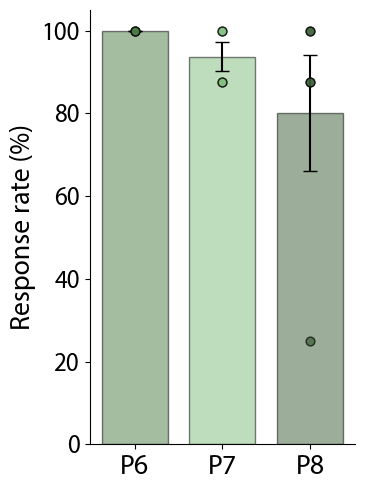

In [94]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Charger les données
df_tac2 = pd.read_excel(file_path)

# Séparer les données par groupe d'âge
df_p6 = df_tac2[df_tac2['age'] == 'P6']
df_p7 = df_tac2[df_tac2['age'] == 'P7']
df_p8 = df_tac2[df_tac2['age'] == 'P8']

# Calcul du taux de réponse moyen par animal et par âge
response_data_p6 = df_p6.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p7 = df_p7.groupby(['animal', 'age'])['response_rate'].mean().reset_index()
response_data_p8 = df_p8.groupby(['animal', 'age'])['response_rate'].mean().reset_index()

# Combiner les données des trois groupes d'âge
combined_data = pd.concat([response_data_p6, response_data_p7, response_data_p8])

# Convertir le taux de réponse en pourcentage
combined_data['response_rate'] = combined_data['response_rate'] * 100

# Définir les âges uniques
ages = sorted(combined_data['age'].unique())

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Extraire les données pour chaque groupe d'âge
data_by_age = [combined_data[combined_data['age'] == age]['response_rate'] for age in ages]

# Test de Kruskal-Wallis
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(combined_data, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge
bar_width = 0.75
positions = range(len(ages))

for i, age in enumerate(ages):
    age_data = combined_data[combined_data['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal
    x_values = [positions[i]] * len(age_data)
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.7,
        marker='o',
        s=40,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})


# Appliquer les réglages de style
plt.tight_layout()

# Sauvegarder les graphiques (décider si nécessaire)
plt.savefig(os.path.join(saving_dir, 'response_rate_age_animal.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'response_rate_age_animal.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()


##### 10.5.2. Response rate (trials)

Statistique H : 7.24651162790685
p-value : 0.026695618879402572
          P6        P7        P8
P6  1.000000  1.000000  0.034961
P7  1.000000  1.000000  0.177099
P8  0.034961  0.177099  1.000000


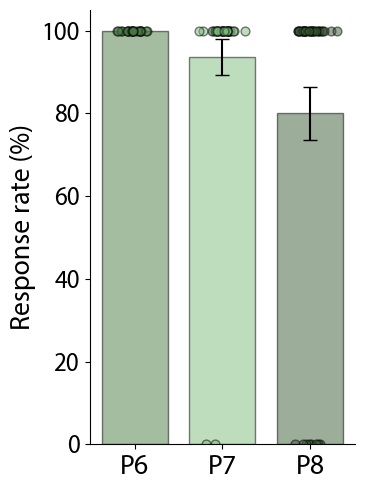

In [95]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
from matplotlib import rcParams


# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'none'
rcParams['font.family'] = 'Myriad Pro'

# Chemin du fichier Excel
file_path = 'G:/PhD/Experimentation/Calcium_imaging_WF/analysis_DFF/raw_data_tac2/Thresholding_tac2/Tac2_responsive_rate.xlsx'

# Charger les données
df = pd.read_excel(file_path)

# Convertir le taux de réponse en pourcentage
df['response_rate'] = df['response_rate'] * 100

# Filtrer les données par groupe d'âge
ages = sorted(df['age'].unique())  # Identifier les groupes d'âge uniques

# Définir les couleurs pour chaque groupe d'âge
colors = {'P6': '#4a7c44', 'P7': '#7dbd7b', 'P8': '#3a5c36'}

# Test de Kruskal-Wallis
data_by_age = [df[df['age'] == age]['response_rate'] for age in ages]
stat, p_value = kruskal(*data_by_age)

# Résultats
print(f"Statistique H : {stat}")
print(f"p-value : {p_value}")

# Test post hoc de Dunn avec correction de Bonferroni
posthoc = posthoc_dunn(df, val_col='response_rate', group_col='age', p_adjust='bonferroni')

# Résultats du test post hoc
print(posthoc)

# Initialiser le graphique
plt.figure(figsize=(3.75, 5))

# Tracer les barres pour chaque groupe d'âge avec les points individuels
bar_width = 0.75
positions = range(len(ages))
jitter_strength = 0.1  # Contrôle l'intensité du jitter

for i, age in enumerate(ages):
    age_data = df[df['age'] == age]
    mean_response = age_data['response_rate'].mean()
    sem_response = age_data['response_rate'].sem()

    # Ajouter une barre avec l'intervalle de confiance (SEM)
    plt.bar(
        positions[i],
        mean_response,
        yerr=sem_response,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        width=bar_width,
        capsize=5,
        label=f'Age {age}',
        alpha=0.5,
    )
    
    # Ajouter les points individuels pour chaque animal avec jitter
    jitter = np.random.normal(0, jitter_strength, size=len(age_data))
    x_values = np.array([positions[i]] * len(age_data)) + jitter
    y_values = age_data['response_rate'].values
    plt.scatter(
        x_values,
        y_values,
        color=colors.get(age, 'gray'),
        edgecolor='black',
        alpha=0.5,
        marker='o',
        s=40,
        zorder=2,
    )

# Réglages des axes et de la légende
plt.xticks(positions, [f'{age}' for age in ages])
plt.ylabel('Response rate (%)')

# Enlever les bordures du haut et de droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 20,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 10   # Taille de la police de la légende
})

plt.tight_layout()


# Sauvegarder les graphiques (optionnel)
plt.savefig(os.path.join(saving_dir, 'response_rate_age_trials.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, 'response_rate_age_trials.svg'), format='svg', dpi=300)

# Afficher le graphique
plt.show()
